# Hotel Bookings EDA

Load the hotel bookings dataset and start exploring it.

In [147]:
# Import libraries

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay, auc
)

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
# Load dataset

df = pd.read_csv("hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0.0,342.0,2015.0,July,27.0,1.0,0.0,0.0,2.0,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01
1,Resort Hotel,0.0,737.0,2015.0,July,27.0,1.0,0.0,0.0,2.0,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01
2,Resort Hotel,0.0,7.0,2015.0,July,27.0,1.0,0.0,1.0,1.0,...,No Deposit,NaN,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02
3,Resort Hotel,0.0,13.0,2015.0,July,27.0,1.0,0.0,1.0,1.0,...,No Deposit,304.0,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02
4,Resort Hotel,0.0,14.0,2015.0,July,27.0,1.0,0.0,2.0,2.0,...,No Deposit,240.0,NaN,0.0,Transient,98.0,0.0,1.0,Check-Out,2015-07-03


In [3]:
# Dataset shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 36683
Columns: 32


In [4]:
# Column names

df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [5]:
# Data types and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36683 entries, 0 to 36682
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           36683 non-null  object 
 1   is_canceled                     36682 non-null  float64
 2   lead_time                       36682 non-null  float64
 3   arrival_date_year               36682 non-null  float64
 4   arrival_date_month              36682 non-null  object 
 5   arrival_date_week_number        36682 non-null  float64
 6   arrival_date_day_of_month       36682 non-null  float64
 7   stays_in_weekend_nights         36682 non-null  float64
 8   stays_in_week_nights            36682 non-null  float64
 9   adults                          36682 non-null  float64
 10  children                        36682 non-null  float64
 11  babies                          36682 non-null  float64
 12  meal                            

In [6]:
# Summary statistics for numeric columns

df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,36682.000000,36682.000000,36682.000000,36682.000000,36682.000000,36682.000000,36682.000000,36682.000000,36682.000000,36682.000000,36682.000000,36682.000000,36682.000000,36682.000000,28819.000000,3008.000000,36682.000000,36682.000000,36682.000000,36682.000000
mean,0.303173,89.928139,2016.040538,27.067117,15.747778,1.167821,3.078431,1.855679,0.120604,0.013222,0.047707,0.111090,0.159779,0.278474,217.267254,240.207447,0.570416,89.195485,0.133362,0.584619
std,0.459636,96.223209,0.701576,14.576372,8.859786,1.147654,2.462141,0.718987,0.433477,0.115883,0.213149,1.394865,1.045964,0.710758,87.336931,125.096882,7.726530,57.575928,0.346169,0.790470
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,10.000000,2016.000000,15.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,154.000000,0.000000,48.000000,0.000000,0.000000
50%,0.000000,54.000000,2016.000000,28.000000,16.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,223.000000,0.000000,72.000000,0.000000,0.000000
75%,1.000000,149.000000,2017.000000,39.000000,23.000000,2.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,242.000000,329.000000,0.000000,114.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,2.000000,1.000000,26.000000,30.000000,17.000000,531.000000,543.000000,185.000000,508.000000,8.000000,5.000000


In [7]:
# Summary statistics for categorical columns

df.describe(include="object")

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,36683,36682,36682,36218,36682,36682,36682,36682,36682,36682,36682,36682
unique,2,12,5,121,6,4,10,11,3,4,3,904
top,Resort Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2017-01-19
freq,36682,3845,27561,16766,15982,26264,21845,15723,34822,27628,25561,147


In [8]:
# Missing values count and percentage

missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2)
})

missing = missing[missing["missing_count"] > 0].sort_values(
    by="missing_percent", 
    ascending=False
)

missing

,missing_count,missing_percent
company,33675,91.80
agent,7864,21.44
country,465,1.27
arrival_date_month,1,0.00
arrival_date_week_number,1,0.00
lead_time,1,0.00
is_canceled,1,0.00
stays_in_weekend_nights,1,0.00
stays_in_week_nights,1,0.00
children,1,0.00


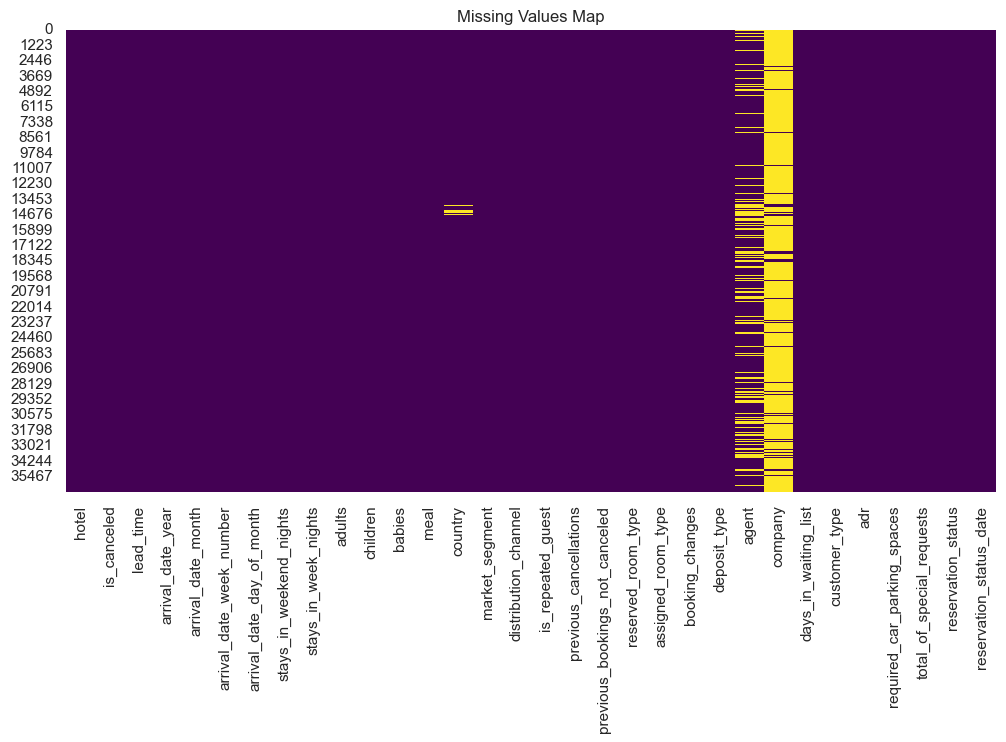

In [9]:
# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Map")
plt.show()

In [10]:
# Fill missing children values with mean, as done in R

df["children"] = df["children"].fillna(df["children"].mean())

df["children"].isnull().sum()
df = df.drop(columns=["company"])
df = df.dropna(subset=["country"])


In [11]:
# Check duplicated rows

duplicate_count = df.duplicated().sum()

print("Duplicated rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_count / len(df) * 100, 2), "%")

Duplicated rows: 5925
Duplicate percentage: 16.36 %


In [12]:
# Remove duplicated rows

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (30293, 31)


In [13]:
# Check target variable distribution

df["is_canceled"].value_counts()

is_canceled
0.0    22348
1.0     7945
Name: count, dtype: int64

In [14]:
# Cancellation rate

cancel_rate = df["is_canceled"].mean() * 100

print("Cancellation rate:", round(cancel_rate, 2), "%")

Cancellation rate: 26.23 %


C:\Users\write\AppData\Local\Temp\ipykernel_39404\2913954688.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancel_counts.index, y=cancel_counts.values, palette=["#378ADD", "#E24B4A"])


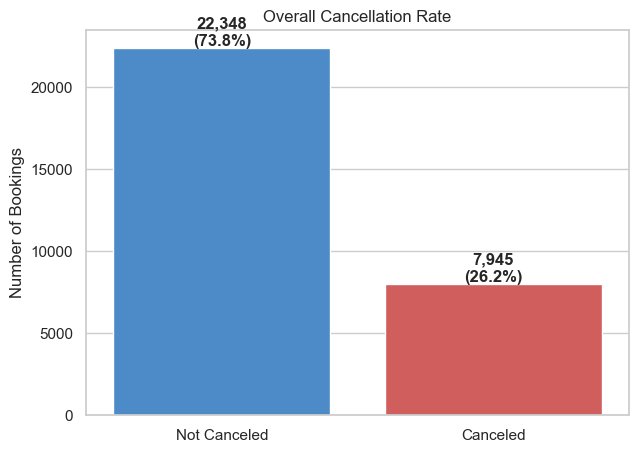

In [15]:
# Plot overall cancellation rate

cancel_counts = df["is_canceled"].value_counts().rename(index={0: "Not Canceled", 1: "Canceled"})

plt.figure(figsize=(7, 5))
sns.barplot(x=cancel_counts.index, y=cancel_counts.values, palette=["#378ADD", "#E24B4A"])

for i, value in enumerate(cancel_counts.values):
    percent = value / cancel_counts.sum() * 100
    plt.text(i, value, f"{value:,}\n({percent:.1f}%)", ha="center", va="bottom", fontweight="bold")

plt.title("Overall Cancellation Rate")
plt.xlabel("")
plt.ylabel("Number of Bookings")
plt.show()

In [16]:
# Cancellation by hotel type

hotel_cancel = pd.crosstab(df["hotel"], df["is_canceled"])
hotel_cancel.columns = ["Not Canceled", "Canceled"]

hotel_cancel

,Not Canceled,Canceled
hotel,,
Resort Hotel,22348,7945


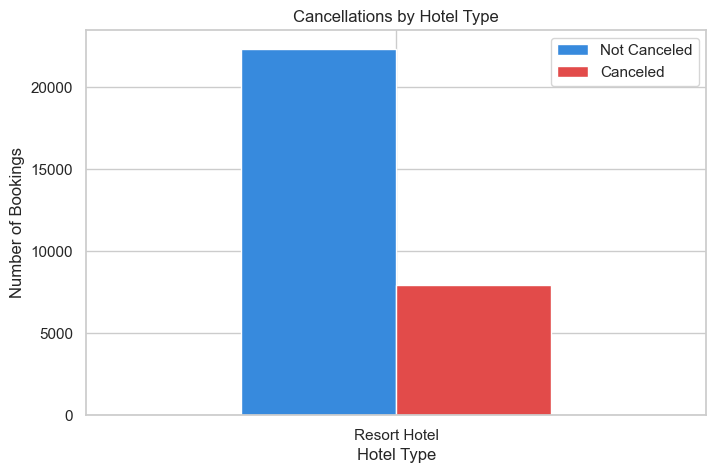

In [17]:
# Plot cancellation by hotel type

hotel_cancel.plot(kind="bar", figsize=(8, 5), color=["#378ADD", "#E24B4A"])

plt.title("Cancellations by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.legend(title="")
plt.show()

In [18]:
# Numeric columns

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

numeric_cols

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

In [19]:
# Outlier count using IQR method

def count_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    return ((series < lower) | (series > upper)).sum()

outlier_summary = pd.DataFrame({
    "column": numeric_cols,
    "outliers": [count_outliers(df[col]) for col in numeric_cols],
    "outlier_percent": [round(count_outliers(df[col]) / len(df) * 100, 2) for col in numeric_cols]
})

outlier_summary.sort_values(by="outliers", ascending=False)

,column,outliers,outlier_percent
14,agent,10470,34.56
7,adults,6747,22.27
13,booking_changes,6191,20.44
17,required_car_parking_spaces,4681,15.45
8,children,2914,9.62
12,previous_bookings_not_canceled,1786,5.90
10,is_repeated_guest,1675,5.53
16,adr,969,3.20
1,lead_time,762,2.52
18,total_of_special_requests,758,2.50


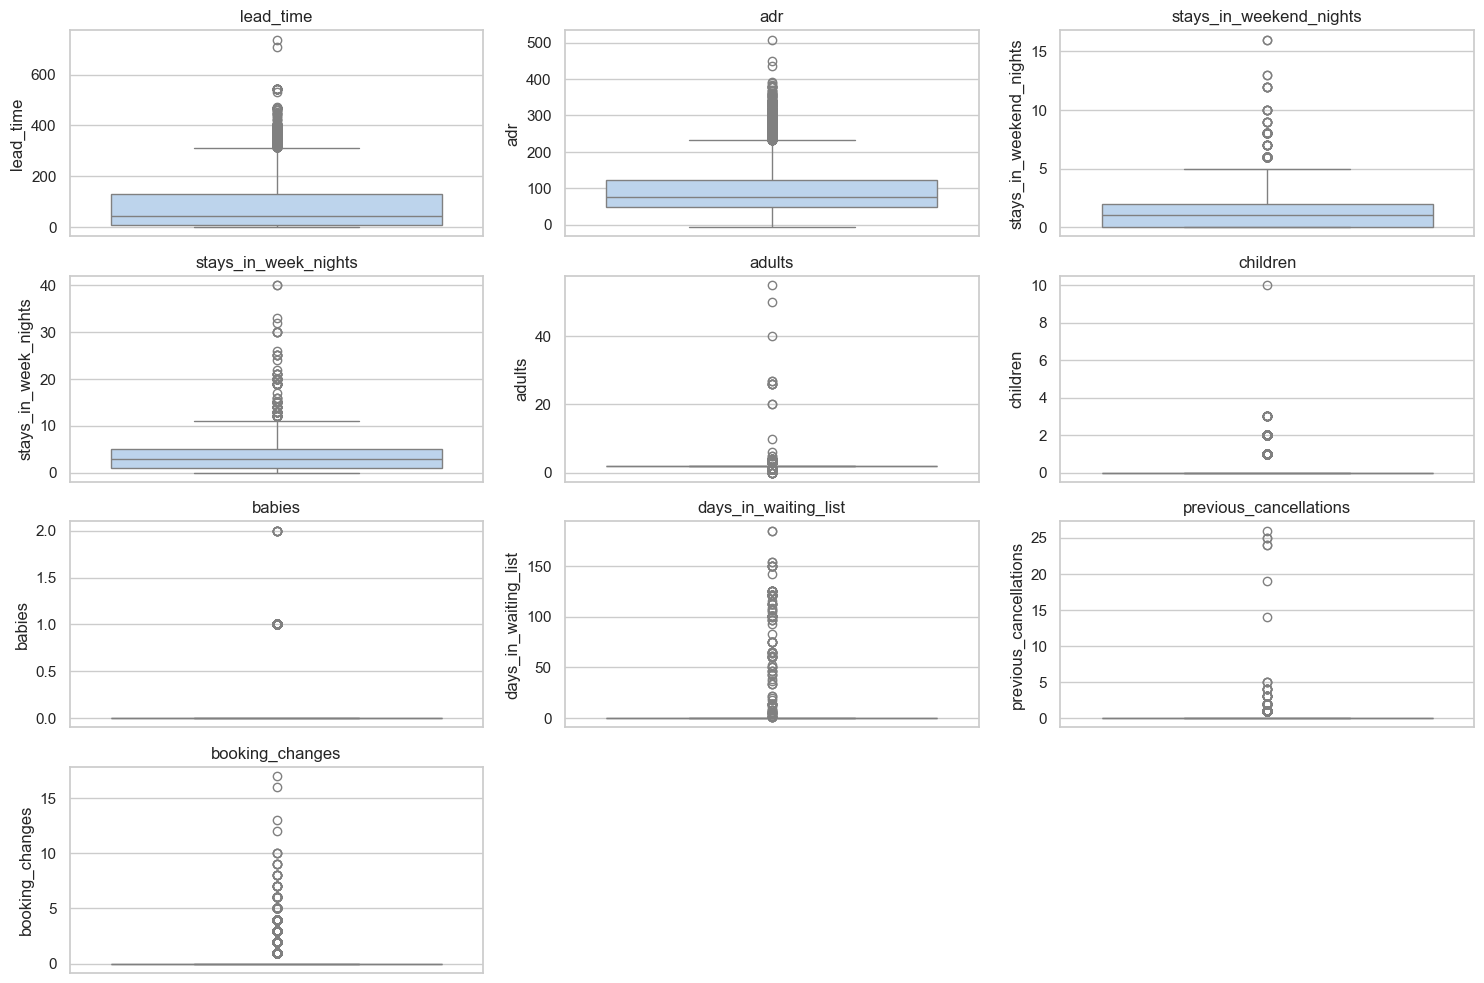

In [20]:
# Boxplots for selected numeric columns

cols_to_check = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "days_in_waiting_list",
    "previous_cancellations",
    "booking_changes"
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_to_check, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col], color="#B5D4F4")
    plt.title(col)

plt.tight_layout()
plt.show()

In [21]:
# Winsorize selected numeric columns to reduce outlier impact

def cap_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    return series.clip(lower, upper)

for col in cols_to_check:
    df[col] = cap_outliers(df[col])

df[cols_to_check].describe()

,lead_time,adr,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,days_in_waiting_list,previous_cancellations,booking_changes
count,30293.000000,30293.000000,30293.000000,30293.000000,30293.0,30293.0,30293.0,30293.0,30293.0,30293.0
mean,79.286205,92.100261,1.189483,3.104678,2.0,0.0,0.0,0.0,0.0,0.0
std,86.459575,56.877675,1.105315,2.291274,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,-6.380000,0.000000,0.000000,2.0,0.0,0.0,0.0,0.0,0.0
25%,8.000000,49.200000,0.000000,1.000000,2.0,0.0,0.0,0.0,0.0,0.0
50%,45.000000,75.000000,1.000000,3.000000,2.0,0.0,0.0,0.0,0.0,0.0
75%,130.000000,123.000000,2.000000,5.000000,2.0,0.0,0.0,0.0,0.0,0.0
max,313.000000,233.700000,5.000000,11.000000,2.0,0.0,0.0,0.0,0.0,0.0


In [22]:
# Check outliers again after winsorizing

outlier_check_after = pd.DataFrame({
    "column": cols_to_check,
    "outliers_after": [count_outliers(df[col]) for col in cols_to_check]
})

outlier_check_after

,column,outliers_after
0,lead_time,0
1,adr,0
2,stays_in_weekend_nights,0
3,stays_in_week_nights,0
4,adults,0
5,children,0
6,babies,0
7,days_in_waiting_list,0
8,previous_cancellations,0
9,booking_changes,0


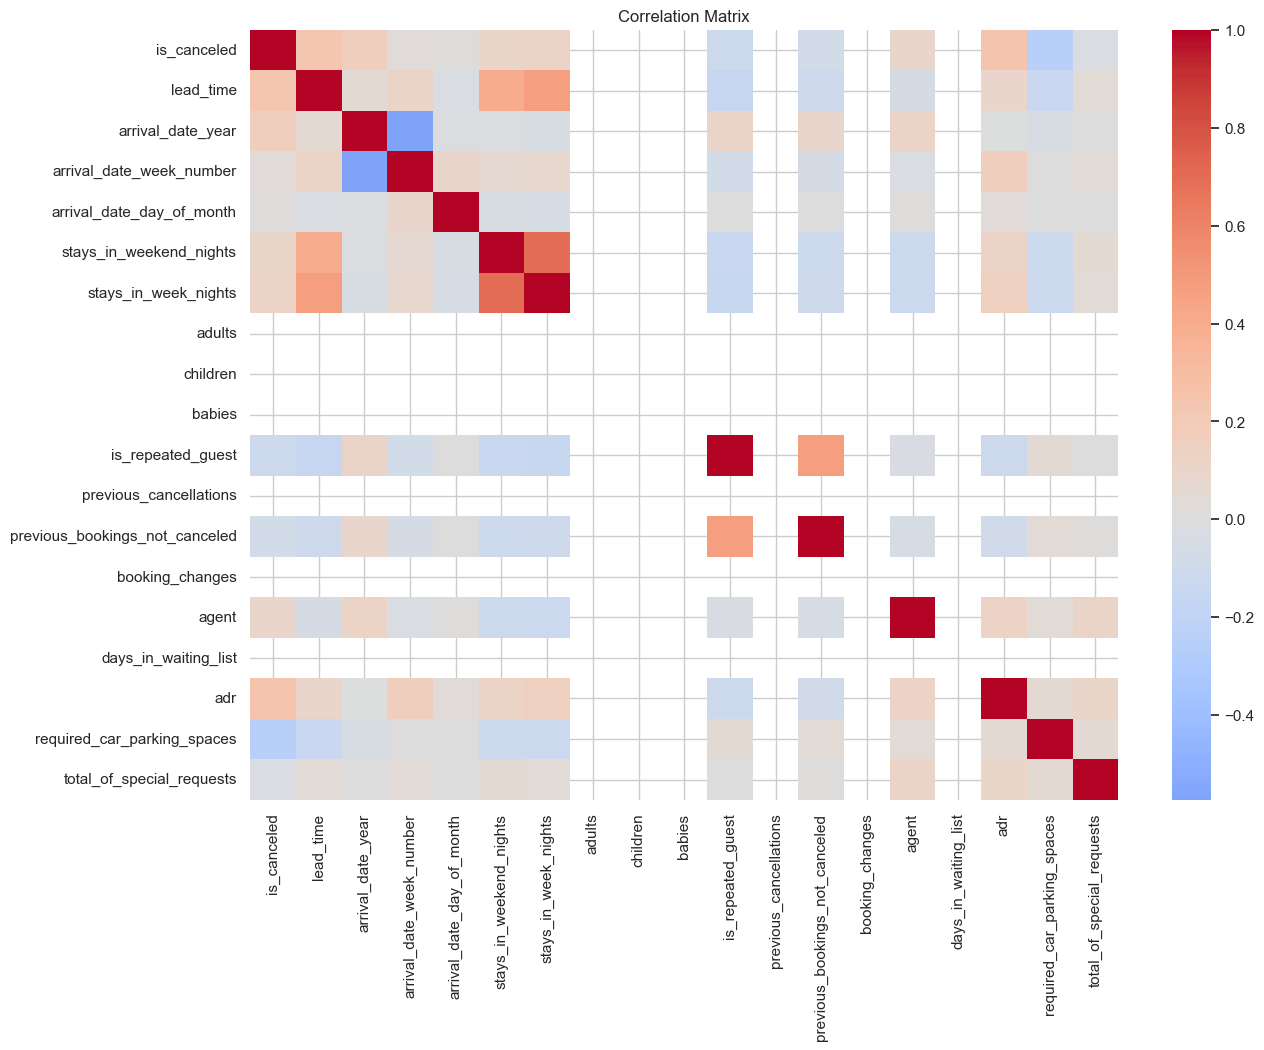

In [23]:
# Correlation matrix for numeric variables

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix")
plt.show()

In [24]:
# Correlation with target variable is_canceled

target_corr = corr_matrix["is_canceled"].drop("is_canceled").sort_values(
    key=abs, 
    ascending=False
)

target_corr

adr                               0.256129
required_car_parking_spaces      -0.251189
lead_time                         0.232467
arrival_date_year                 0.168378
stays_in_week_nights              0.122282
is_repeated_guest                -0.120608
stays_in_weekend_nights           0.108606
agent                             0.102159
previous_bookings_not_canceled   -0.079715
total_of_special_requests        -0.031921
arrival_date_week_number          0.026537
arrival_date_day_of_month         0.014174
adults                                 NaN
children                               NaN
babies                                 NaN
previous_cancellations                 NaN
booking_changes                        NaN
days_in_waiting_list                   NaN
Name: is_canceled, dtype: float64

C:\Users\write\AppData\Local\Temp\ipykernel_39404\2967574722.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


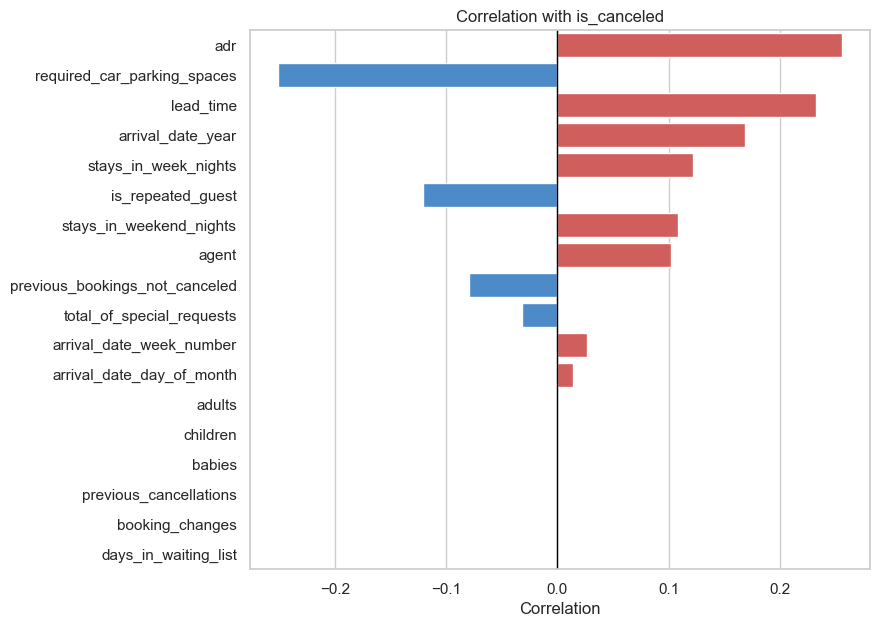

In [25]:
# Plot correlation with is_canceled

plt.figure(figsize=(8, 7))
sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    palette=["#E24B4A" if x > 0 else "#378ADD" for x in target_corr.values]
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Correlation with is_canceled")
plt.xlabel("Correlation")
plt.ylabel("")
plt.show()

In [26]:
# Cancellation by deposit type

deposit_cancel = pd.crosstab(
    df["deposit_type"], 
    df["is_canceled"], 
    normalize="index"
) * 100

deposit_cancel.columns = ["Not Canceled", "Canceled"]

deposit_cancel

,Not Canceled,Canceled
deposit_type,,
No Deposit,74.117765,25.882235
Non Refund,15.625000,84.375000
Refundable,82.608696,17.391304


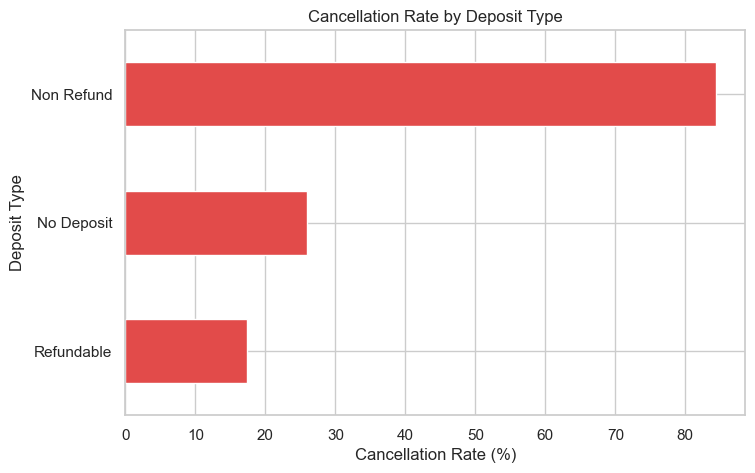

In [27]:
# Plot cancellation rate by deposit type

deposit_cancel["Canceled"].sort_values().plot(
    kind="barh",
    color="#E24B4A",
    figsize=(8, 5)
)

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Deposit Type")
plt.show()

In [28]:
# Cancellation by market segment

market_cancel = pd.crosstab(
    df["market_segment"], 
    df["is_canceled"], 
    normalize="index"
) * 100

market_cancel.columns = ["Not Canceled", "Canceled"]

market_cancel.sort_values(by="Canceled", ascending=False)

,Not Canceled,Canceled
market_segment,,
Online TA,62.115398,37.884602
Groups,80.151650,19.848350
Complementary,82.080925,17.919075
Direct,85.032258,14.967742
Offline TA/TO,86.367529,13.632471
Corporate,86.712095,13.287905


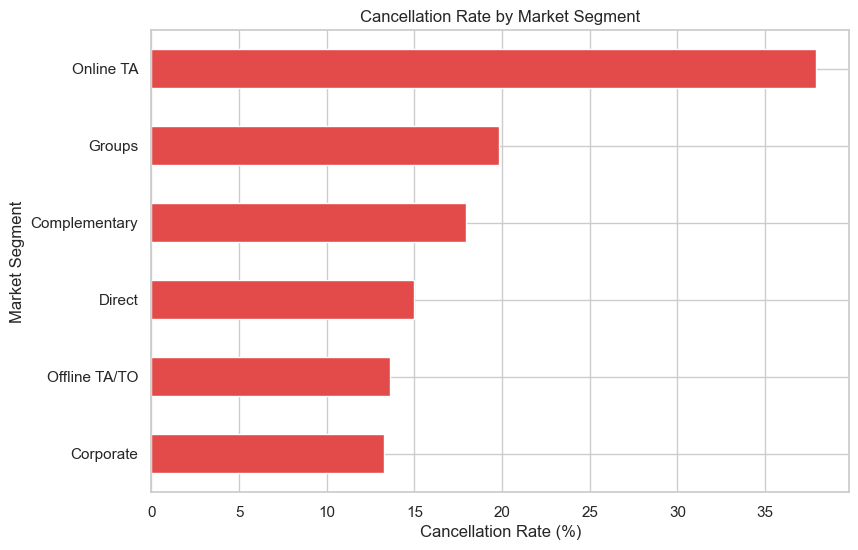

In [29]:
# Plot cancellation rate by market segment

market_cancel["Canceled"].sort_values().plot(
    kind="barh",
    color="#E24B4A",
    figsize=(9, 6)
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Market Segment")
plt.show()

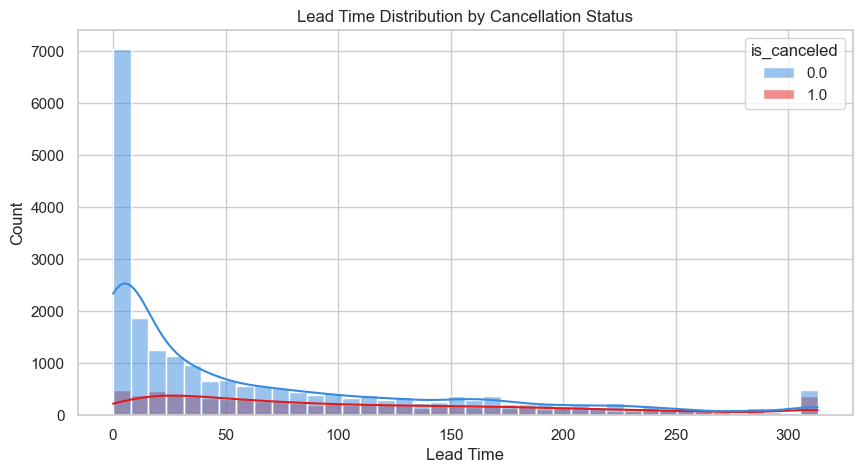

In [30]:
# Lead time distribution by cancellation status

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="lead_time",
    hue="is_canceled",
    bins=40,
    kde=True,
    palette={0: "#378ADD", 1: "#E41A1A"}
)

plt.title("Lead Time Distribution by Cancellation Status")
plt.xlabel("Lead Time")
plt.ylabel("Count")
plt.show()

In [31]:
# Cancellation rate by lead time group

lead_time_bins = [0, 7, 30, 90, 180, 365]
lead_time_labels = ["0-7 days", "8-30 days", "31-90 days", "91-180 days", "181-365 days"]

# Only add 365+ bin if the maximum lead time is greater than 365
if df["lead_time"].max() > 365:
    lead_time_bins.append(df["lead_time"].max())
    lead_time_labels.append("365+ days")

df["lead_time_group"] = pd.cut(
    df["lead_time"],
    bins=lead_time_bins,
    labels=lead_time_labels,
    include_lowest=True
)

lead_time_cancel = df.groupby("lead_time_group", observed=False)["is_canceled"].mean() * 100

lead_time_cancel

lead_time_group
0-7 days         6.516257
8-30 days       22.734139
31-90 days      31.788641
91-180 days     36.531555
181-365 days    41.084417
Name: is_canceled, dtype: float64

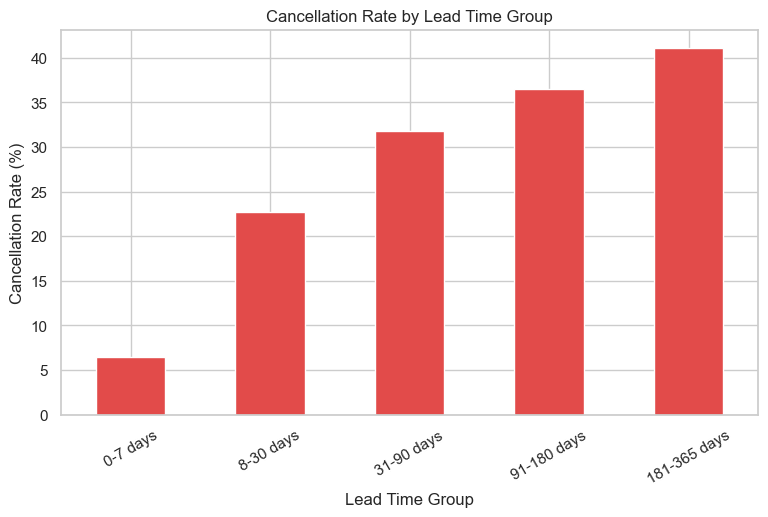

In [32]:
# Plot cancellation rate by lead time group

lead_time_cancel.plot(kind="bar", color="#E24B4A", figsize=(9, 5))

plt.title("Cancellation Rate by Lead Time Group")
plt.xlabel("Lead Time Group")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=30)
plt.show()

In [33]:
# Cancellation by repeated guest status

repeated_cancel = pd.crosstab(
    df["is_repeated_guest"],
    df["is_canceled"],
    normalize="index"
) * 100

repeated_cancel.columns = ["Not Canceled", "Canceled"]
repeated_cancel.index = ["New Guest", "Repeated Guest"]

repeated_cancel

,Not Canceled,Canceled
New Guest,72.489342,27.510658
Repeated Guest,95.701493,4.298507


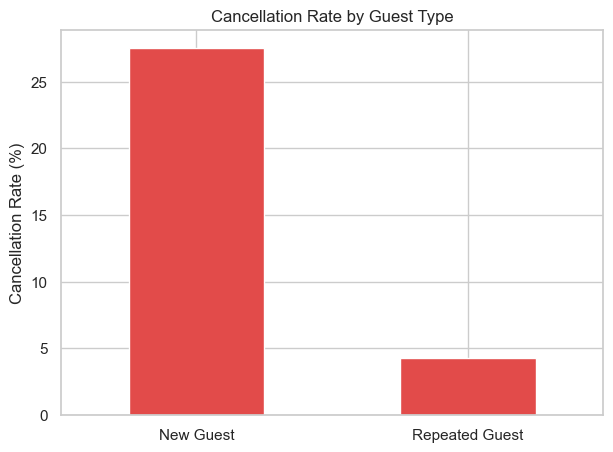

In [34]:
# Plot cancellation by repeated guest

repeated_cancel["Canceled"].plot(
    kind="bar",
    color="#E24B4A",
    figsize=(7, 5)
)

plt.title("Cancellation Rate by Guest Type")
plt.xlabel("")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [35]:
# Room match: reserved room type vs assigned room type

df["room_match"] = np.where(
    df["reserved_room_type"] == df["assigned_room_type"],
    "Matched",
    "Changed"
)

room_cancel = pd.crosstab(
    df["room_match"],
    df["is_canceled"],
    normalize="index"
) * 100

room_cancel.columns = ["Not Canceled", "Canceled"]

room_cancel

,Not Canceled,Canceled
room_match,,
Changed,95.436908,4.563092
Matched,67.920335,32.079665


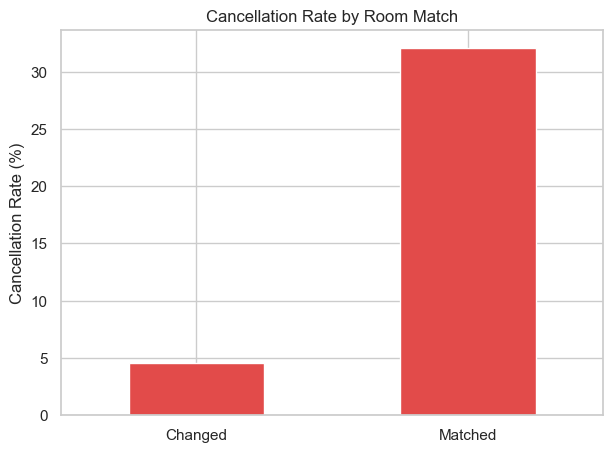

In [36]:
# Plot cancellation rate by room match

room_cancel["Canceled"].plot(
    kind="bar",
    color="#E24B4A",
    figsize=(7, 5)
)

plt.title("Cancellation Rate by Room Match")
plt.xlabel("")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [37]:
# Cancellation by total special requests

special_cancel = df.groupby("total_of_special_requests")["is_canceled"].mean() * 100

special_cancel

total_of_special_requests
0.0    27.706730
1.0    24.257784
2.0    26.037234
3.0    22.052067
4.0    14.583333
5.0     0.000000
Name: is_canceled, dtype: float64

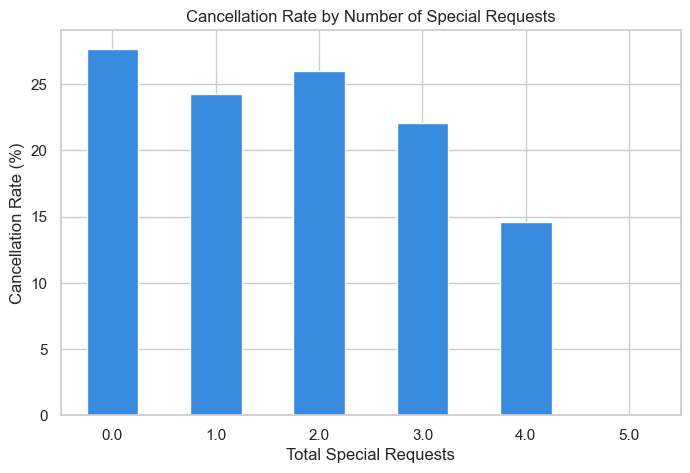

In [38]:
# Plot cancellation by special requests

special_cancel.plot(
    kind="bar",
    color="#378ADD",
    figsize=(8, 5)
)

plt.title("Cancellation Rate by Number of Special Requests")
plt.xlabel("Total Special Requests")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [39]:
# Monthly seasonality

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_cancel = df.groupby("arrival_date_month")["is_canceled"].mean().reindex(month_order) * 100

monthly_cancel

arrival_date_month
January      14.308176
February     18.013952
March        17.825586
April        23.459885
May          26.456033
June         45.192830
July         39.439195
August       41.664370
September    23.522117
October      19.095665
November     15.258449
December     19.052224
Name: is_canceled, dtype: float64

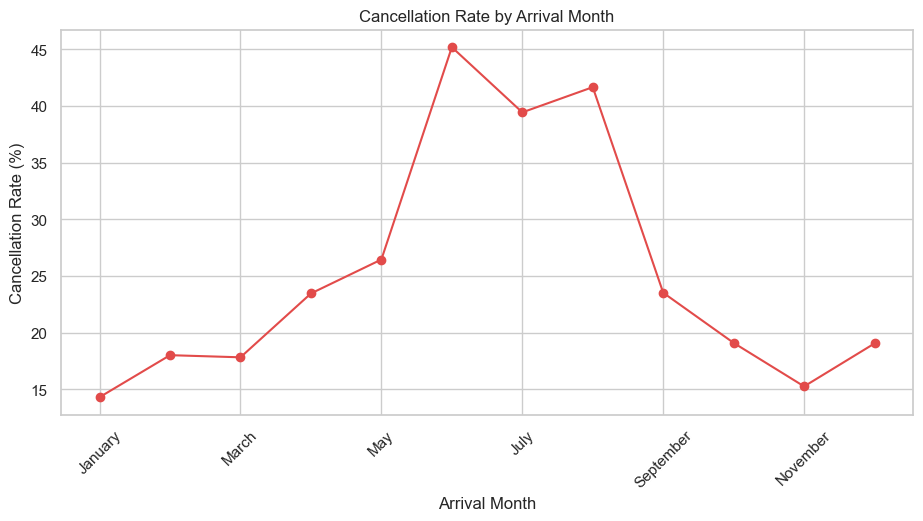

In [40]:
# Plot monthly cancellation rate

monthly_cancel.plot(
    kind="line",
    marker="o",
    color="#E24B4A",
    figsize=(11, 5)
)

plt.title("Cancellation Rate by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [41]:
# Top countries by number of bookings

top_countries = df["country"].value_counts().head(10)

top_countries

country
PRT    13399
GBR     5155
ESP     3106
IRL     1714
FRA     1312
DEU      854
NLD      454
CN       403
ITA      377
USA      359
Name: count, dtype: int64

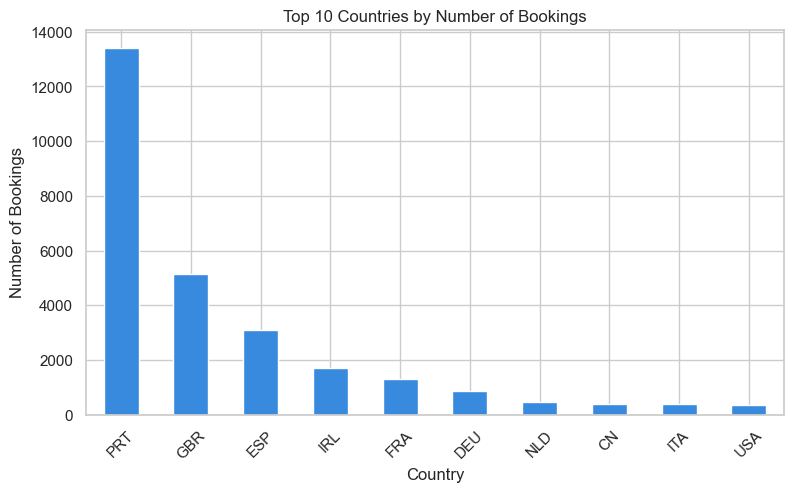

In [42]:
# Plot top countries

top_countries.plot(
    kind="bar",
    color="#378ADD",
    figsize=(9, 5)
)

plt.title("Top 10 Countries by Number of Bookings")
plt.xlabel("Country")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

Feature Engineering

we must remove columns that reveal the final outcome after the booking is already completed or canceled. These columns should be removed: reservation_status
reservation_status_date Because reservation_status directly tells us whether the booking was canceled, checked out, or no-show. If we leave it in the model, the model will “cheat” and give unrealistically high accuracy.

In [43]:
# 1. Total length of stay

df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

df[["stays_in_weekend_nights", "stays_in_week_nights", "total_nights"]].head()

,stays_in_weekend_nights,stays_in_week_nights,total_nights
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,1.0,1.0
3,0.0,1.0,1.0
4,0.0,2.0,2.0


In [44]:
# 2. Total number of guests

df["total_guests"] = df["adults"] + df["children"] + df["babies"]

df[["adults", "children", "babies", "total_guests"]].head()

,adults,children,babies,total_guests
0,2.0,0.0,0.0,2.0
1,2.0,0.0,0.0,2.0
2,2.0,0.0,0.0,2.0
3,2.0,0.0,0.0,2.0
4,2.0,0.0,0.0,2.0


In [45]:
# 3. Room match: whether reserved and assigned room types are the same

df["room_match"] = np.where(
    df["reserved_room_type"] == df["assigned_room_type"],
    1,
    0
)

df[["reserved_room_type", "assigned_room_type", "room_match"]].head()

,reserved_room_type,assigned_room_type,room_match
0,C,C,1
1,C,C,1
2,A,C,0
3,A,A,1
4,A,A,1


In [46]:
# 4. High season flag

high_season_months = ["June", "July", "August", "September"]

df["is_high_season"] = np.where(
    df["arrival_date_month"].isin(high_season_months),
    1,
    0
)

df[["arrival_date_month", "is_high_season"]].head()

,arrival_date_month,is_high_season
0,July,1
1,July,1
2,July,1
3,July,1
4,July,1


In [47]:
# 5. Simple cancellation risk score

df["cancel_risk_score"] = (
    df["lead_time"] 
    + df["previous_cancellations"] * 10 
    - df["booking_changes"]
)

df[["lead_time", "previous_cancellations", "booking_changes", "cancel_risk_score"]].head()

,lead_time,previous_cancellations,booking_changes,cancel_risk_score
0,313.0,0.0,0.0,313.0
1,313.0,0.0,0.0,313.0
2,7.0,0.0,0.0,7.0
3,13.0,0.0,0.0,13.0
4,14.0,0.0,0.0,14.0


In [48]:
# 6. ADR price tier using quartiles

df["adr_bin"] = pd.qcut(
    df["adr"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"],
    duplicates="drop"
)

df[["adr", "adr_bin"]].head()

,adr,adr_bin
0,0.0,Low
1,0.0,Low
2,75.0,Medium-Low
3,75.0,Medium-Low
4,98.0,Medium-High


In [49]:
# 7. Has special requests

df["has_special_requests"] = np.where(
    df["total_of_special_requests"] > 0,
    1,
    0
)

df[["total_of_special_requests", "has_special_requests"]].head()

,total_of_special_requests,has_special_requests
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,1.0,1


In [50]:
# 8. Guest loyalty indicator

df["guest_loyalty"] = (
    df["is_repeated_guest"] 
    + df["previous_bookings_not_canceled"]
)

df[["is_repeated_guest", "previous_bookings_not_canceled", "guest_loyalty"]].head()

,is_repeated_guest,previous_bookings_not_canceled,guest_loyalty
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


In [51]:
# 9. Weekend ratio

df["weekend_ratio"] = np.where(
    df["total_nights"] > 0,
    df["stays_in_weekend_nights"] / df["total_nights"],
    0
)

df[["stays_in_weekend_nights", "total_nights", "weekend_ratio"]].head()

,stays_in_weekend_nights,total_nights,weekend_ratio
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,2.0,0.0


In [52]:
# 10. Booked via agent

df["booked_via_agent"] = np.where(
    df["agent"].notna(),
    1,
    0
)

df[["agent", "booked_via_agent"]].head()

,agent,booked_via_agent
0,NaN,0
1,NaN,0
2,NaN,0
3,304.0,1
4,240.0,1


In [53]:
# Drop columns with high missingness after extracting booked_via_agent

df = df.drop(columns=["agent"])

df.shape

(30293, 41)

In [54]:
# Preview engineered features

engineered_features = [
    "total_nights",
    "total_guests",
    "room_match",
    "is_high_season",
    "cancel_risk_score",
    "adr_bin",
    "has_special_requests",
    "guest_loyalty",
    "weekend_ratio",
    "booked_via_agent"
]

df[engineered_features].head()

,total_nights,total_guests,room_match,is_high_season,cancel_risk_score,adr_bin,has_special_requests,guest_loyalty,weekend_ratio,booked_via_agent
0,0.0,2.0,1,1,313.0,Low,0,0.0,0.0,0
1,0.0,2.0,1,1,313.0,Low,0,0.0,0.0,0
2,1.0,2.0,0,1,7.0,Medium-Low,0,0.0,0.0,0
3,1.0,2.0,1,1,13.0,Medium-Low,0,0.0,0.0,1
4,2.0,2.0,1,1,14.0,Medium-High,1,0.0,0.0,1


In [55]:
# Check missing values after feature engineering

missing_after_engineering = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2)
})

missing_after_engineering[missing_after_engineering["missing_count"] > 0].sort_values(
    by="missing_percent",
    ascending=False
)

,missing_count,missing_percent


Modeling

In [56]:
# Remove leakage columns

leakage_cols = [
    "reservation_status",
    "reservation_status_date"
]

df_model = df.drop(columns=leakage_cols)

df_model.shape

(30293, 39)

In [57]:
# Separate target and features

X = df_model.drop(columns=["is_canceled"])
y = df_model["is_canceled"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (30293, 38)
Target shape: (30293,)


In [58]:
# Identify categorical and numeric columns

categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumeric columns:")
print(numeric_cols)

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'lead_time_group', 'adr_bin']

Numeric columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'room_match', 'total_nights', 'total_guests', 'is_high_season', 'cancel_risk_score', 'has_special_requests', 'guest_loyalty', 'weekend_ratio', 'booked_via_agent']


In [59]:
# One-hot encode categorical variables

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

X_encoded.shape

(30293, 198)

In [60]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (24234, 198)
Testing features: (6059, 198)


In [61]:
# Scale data for Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [113]:
def evaluate_model(model_name, y_test, y_pred, y_prob=None):
    results = {
        "Model":     model_name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1 Score":  f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
    }

    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        prec, rec, _ = precision_recall_curve(y_test, y_prob)
        roc_auc_val = auc(fpr, tpr)
        pr_auc_val  = auc(rec, prec)

        order   = np.argsort(y_prob)[::-1]
        cum_pos = np.cumsum(np.array(y_test)[order]) / np.array(y_test).sum()
        cum_pop = np.arange(1, len(y_test) + 1) / len(y_test)
        gini    = 2 * auc(cum_pop, cum_pos) - 1

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle(model_name, fontsize=14, fontweight="bold")

        # --- Row 1: the 3 curves ---

        # ROC Curve
        axes[0, 0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.3f}")
        axes[0, 0].plot([0, 1], [0, 1], "k--", lw=1)
        axes[0, 0].set(title="ROC Curve", xlabel="FPR", ylabel="TPR")
        axes[0, 0].legend(loc="lower right")

        # PR Curve
        axes[0, 1].plot(rec, prec, lw=2, label=f"PR-AUC = {pr_auc_val:.3f}")
        axes[0, 1].set(title="PR Curve", xlabel="Recall", ylabel="Precision")
        axes[0, 1].legend(loc="upper right")

        # Lorenz Curve
        axes[0, 2].plot(cum_pop, cum_pos, lw=2, label=f"Gini = {gini:.3f}")
        axes[0, 2].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
        axes[0, 2].fill_between(cum_pop, cum_pos, cum_pop, alpha=0.15)
        axes[0, 2].set(title="Lorenz Curve", xlabel="% Population", ylabel="% Positives")
        axes[0, 2].legend(loc="lower right")

        # --- Row 2: Confusion Matrix + Metrics table ---

        # Confusion Matrix
        ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=axes[1, 0], colorbar=False)
        axes[1, 0].set_title("Confusion Matrix")

        # Metrics table
        axes[1, 1].axis("off")
        metric_names  = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
        metric_values = [f"{results[m]:.4f}" for m in metric_names]
        table = axes[1, 1].table(
            cellText=[[v] for v in metric_values],
            rowLabels=metric_names,
            colLabels=["Score"],
            loc="center",
            cellLoc="center",
        )
        table.scale(1.4, 2.5)
        table.auto_set_font_size(False)
        table.set_fontsize(12)
        axes[1, 1].set_title("Metrics", pad=12)

        # Hide unused bottom-right cell
        axes[1, 2].axis("off")

        plt.tight_layout()
        plt.show()

    return results



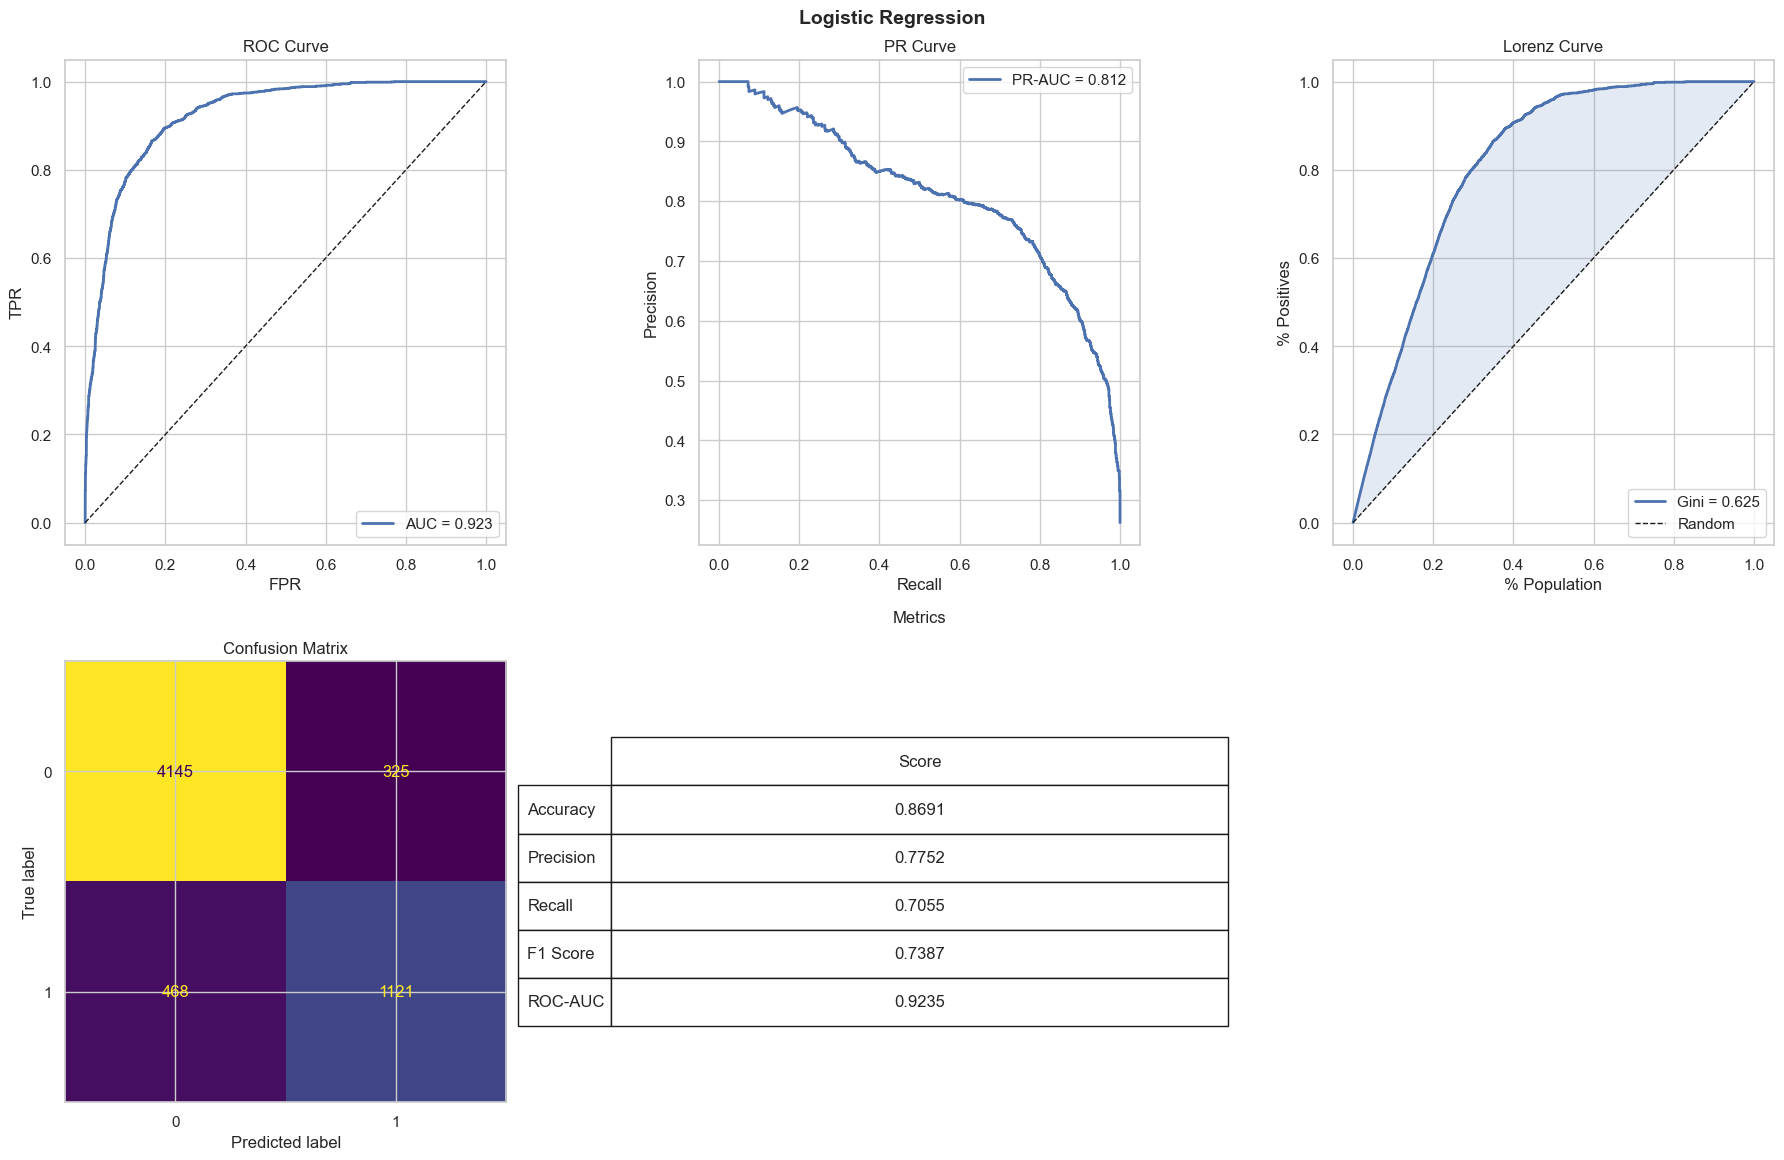

{'Model': 'Logistic Regression',
 'Accuracy': 0.8691203168839743,
 'Precision': 0.7752420470262794,
 'Recall': 0.7054751415984896,
 'F1 Score': 0.7387149917627677,
 'ROC-AUC': np.float64(0.9234652948191073)}

In [114]:
# Logistic Regression model

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

log_results = evaluate_model(
    "Logistic Regression",
    y_test,
    log_pred,
    log_prob
)

log_results

In [119]:
# Logistic Regression classification report

print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

         0.0       0.90      0.93      0.91      4470
         1.0       0.78      0.71      0.74      1589

    accuracy                           0.87      6059
   macro avg       0.84      0.82      0.83      6059
weighted avg       0.87      0.87      0.87      6059



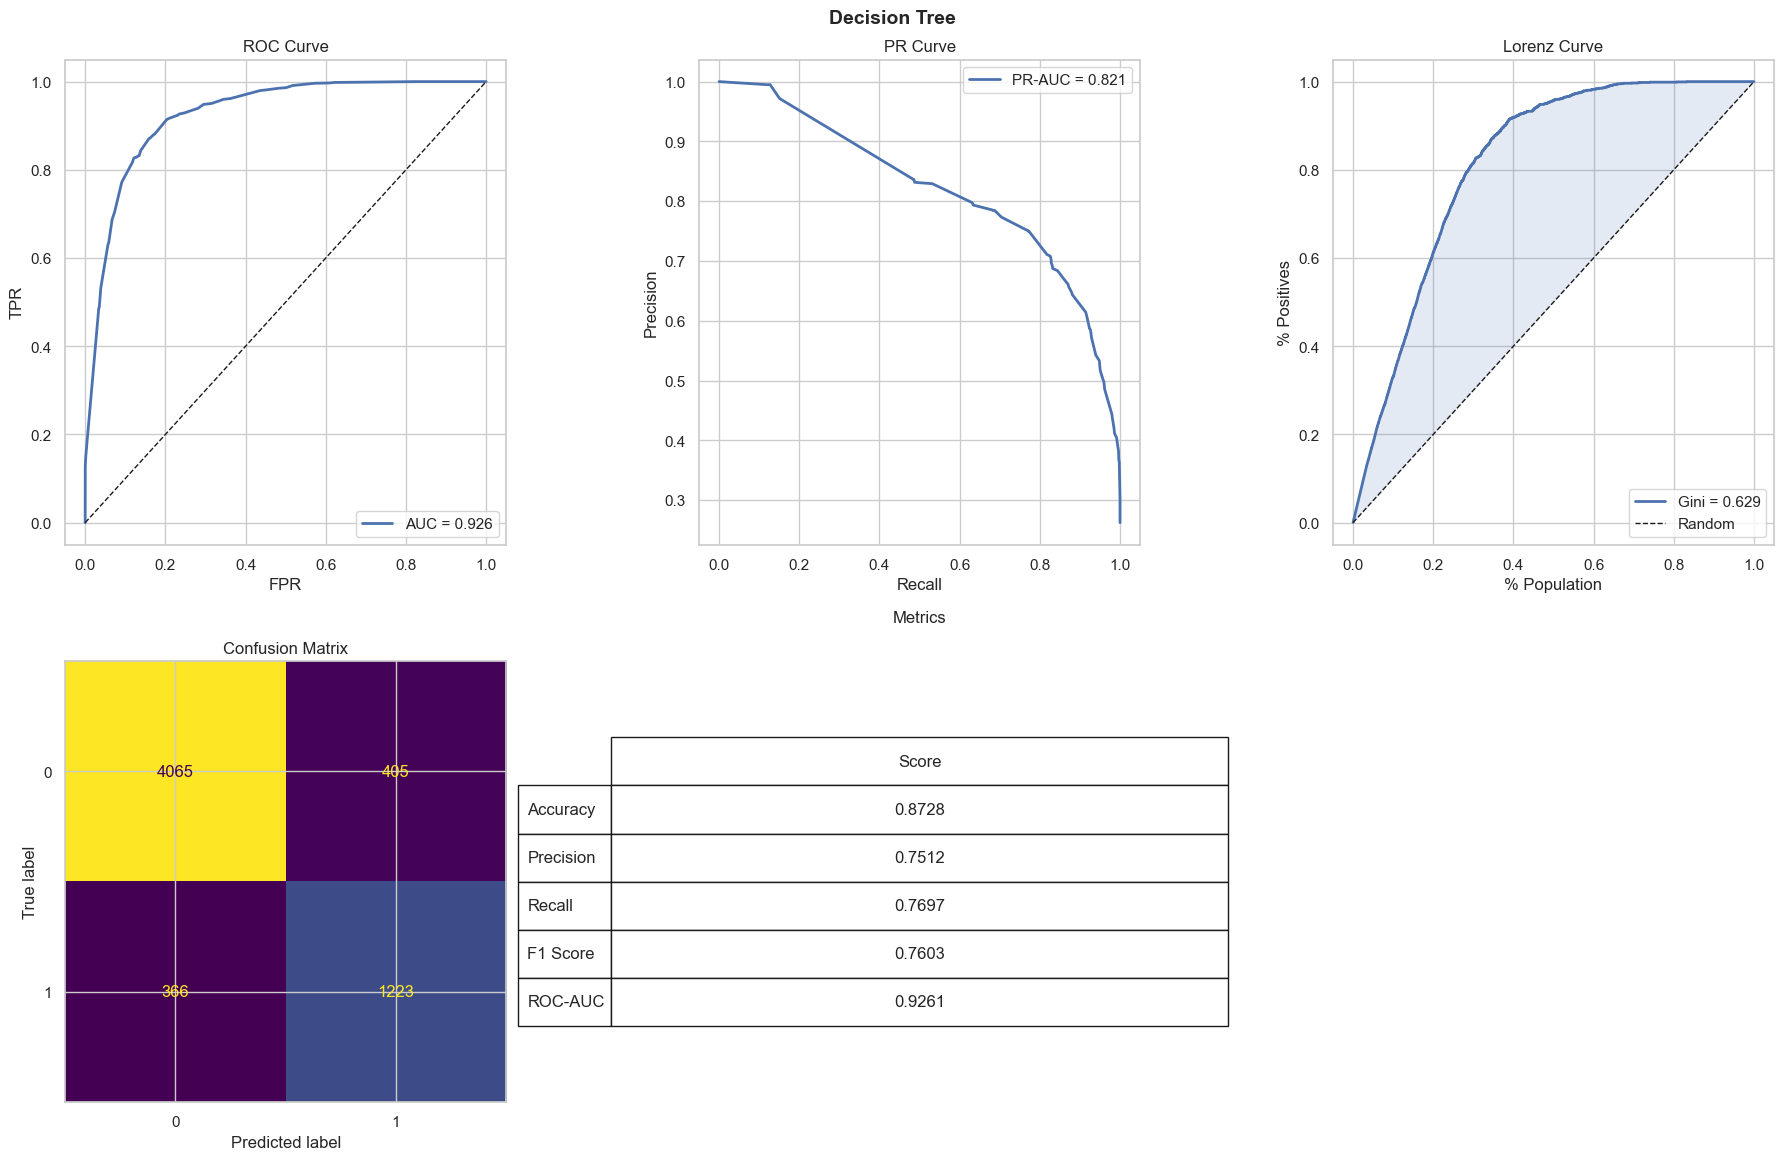

{'Model': 'Decision Tree',
 'Accuracy': 0.8727512790889586,
 'Precision': 0.7512285012285013,
 'Recall': 0.7696664568911264,
 'F1 Score': 0.7603357165060616,
 'ROC-AUC': np.float64(0.9261012863886648)}

In [120]:
# Decision Tree model

tree_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=50,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_prob = tree_model.predict_proba(X_test)[:, 1]

tree_results = evaluate_model(
    "Decision Tree",
    y_test,
    tree_pred,
    tree_prob
)

tree_results

In [121]:
# Decision Tree classification report

print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.91      0.91      4470
         1.0       0.75      0.77      0.76      1589

    accuracy                           0.87      6059
   macro avg       0.83      0.84      0.84      6059
weighted avg       0.87      0.87      0.87      6059



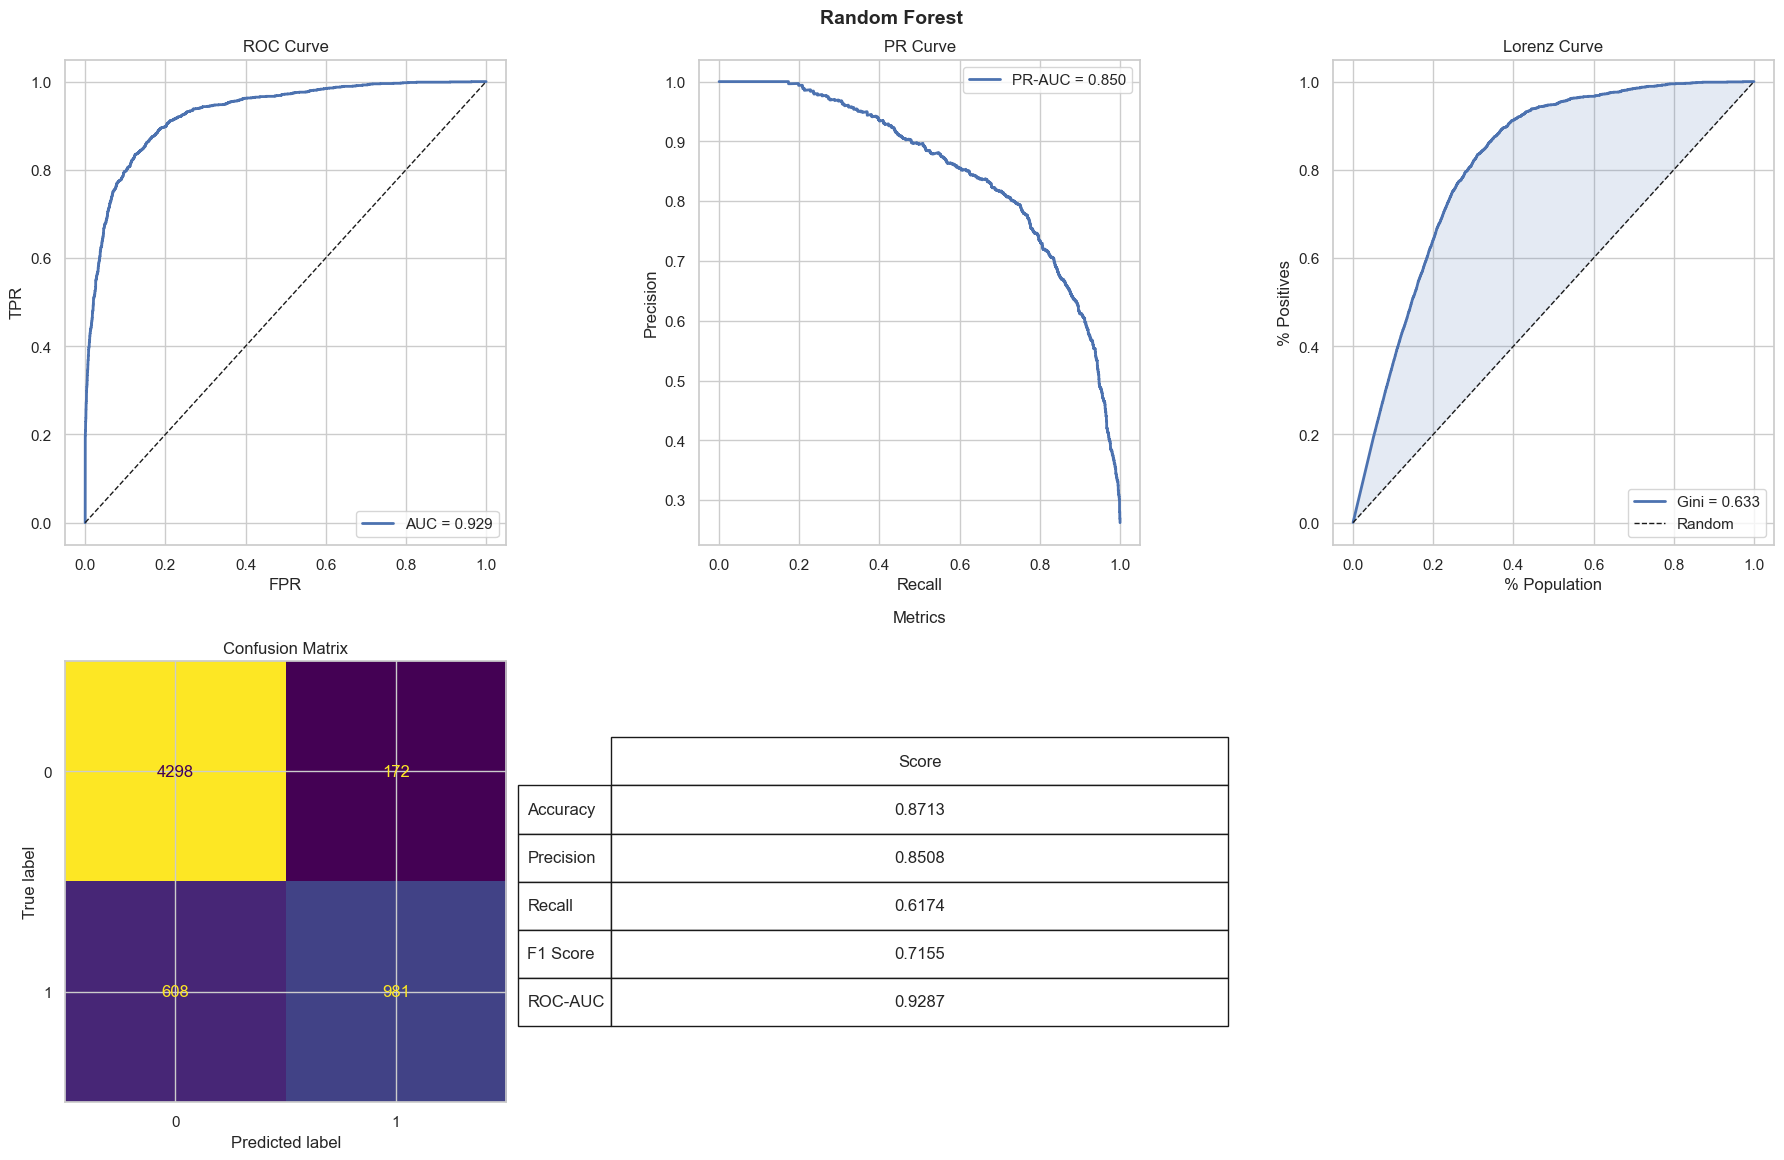

{'Model': 'Random Forest',
 'Accuracy': 0.8712658854596468,
 'Precision': 0.8508239375542064,
 'Recall': 0.617369414726243,
 'F1 Score': 0.7155361050328227,
 'ROC-AUC': np.float64(0.9287123583135173)}

In [122]:
# Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=50,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

rf_results

In [123]:
# Random Forest classification report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.96      0.92      4470
         1.0       0.85      0.62      0.72      1589

    accuracy                           0.87      6059
   macro avg       0.86      0.79      0.82      6059
weighted avg       0.87      0.87      0.86      6059



In [124]:
# Compare all model results

model_results = pd.DataFrame([
    log_results,
    tree_results,
    rf_results
])

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.869120,0.775242,0.705475,0.738715,0.923465
1,Decision Tree,0.872751,0.751229,0.769666,0.760336,0.926101
2,Random Forest,0.871266,0.850824,0.617369,0.715536,0.928712


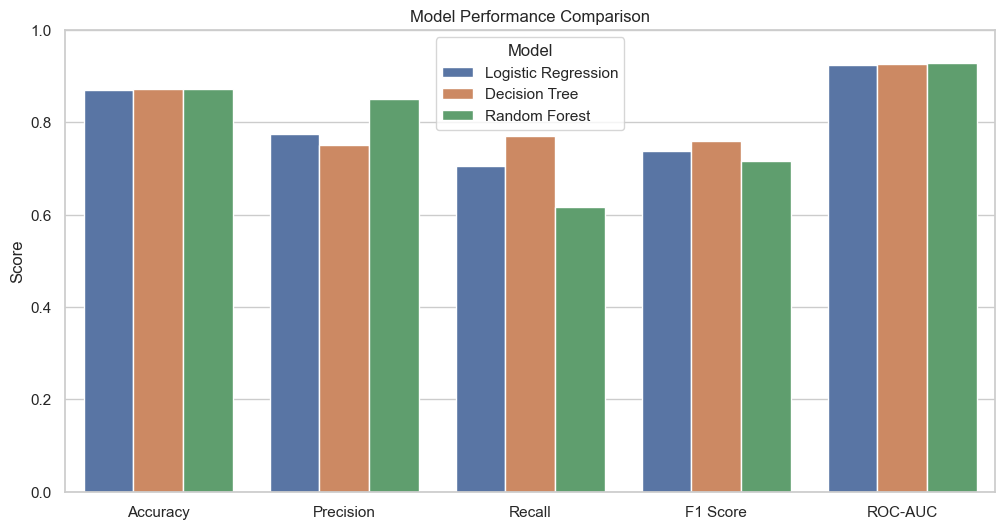

In [125]:
# Plot model comparison

model_results_melted = model_results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=model_results_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("")
plt.legend(title="Model")
plt.show()

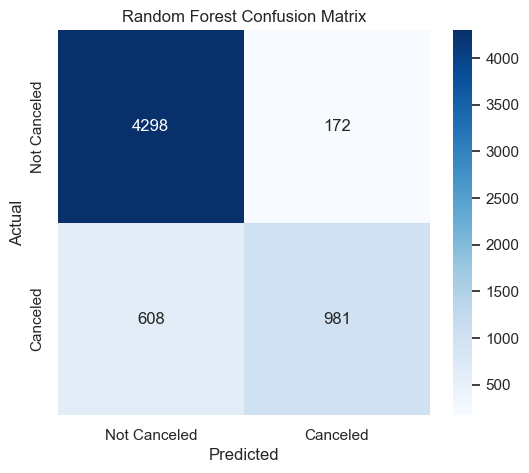

In [126]:
# Confusion matrix for Random Forest

rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Canceled", "Canceled"],
    yticklabels=["Not Canceled", "Canceled"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [127]:
# Feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
133,country_PRT,0.111186
15,required_car_parking_spaces,0.085651
0,lead_time,0.081451
1,arrival_date_year,0.081160
21,cancel_risk_score,0.073214
17,room_match,0.070776
165,market_segment_Online TA,0.049068
14,adr,0.041583
164,market_segment_Offline TA/TO,0.029925
197,adr_bin_High,0.028364


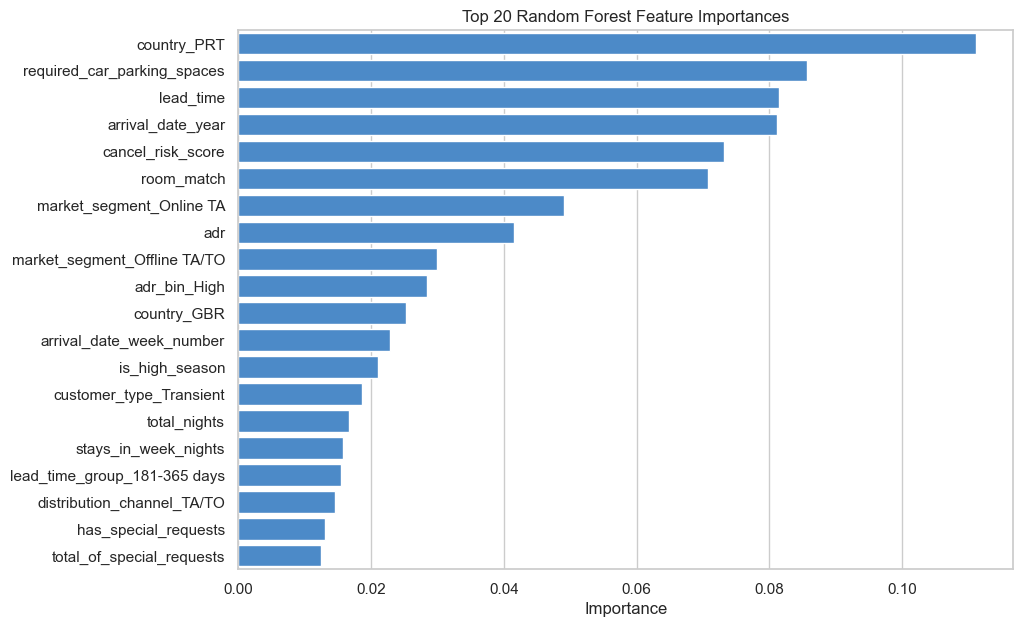

In [128]:
# Plot top 20 important features

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    color="#378ADD"
)

plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

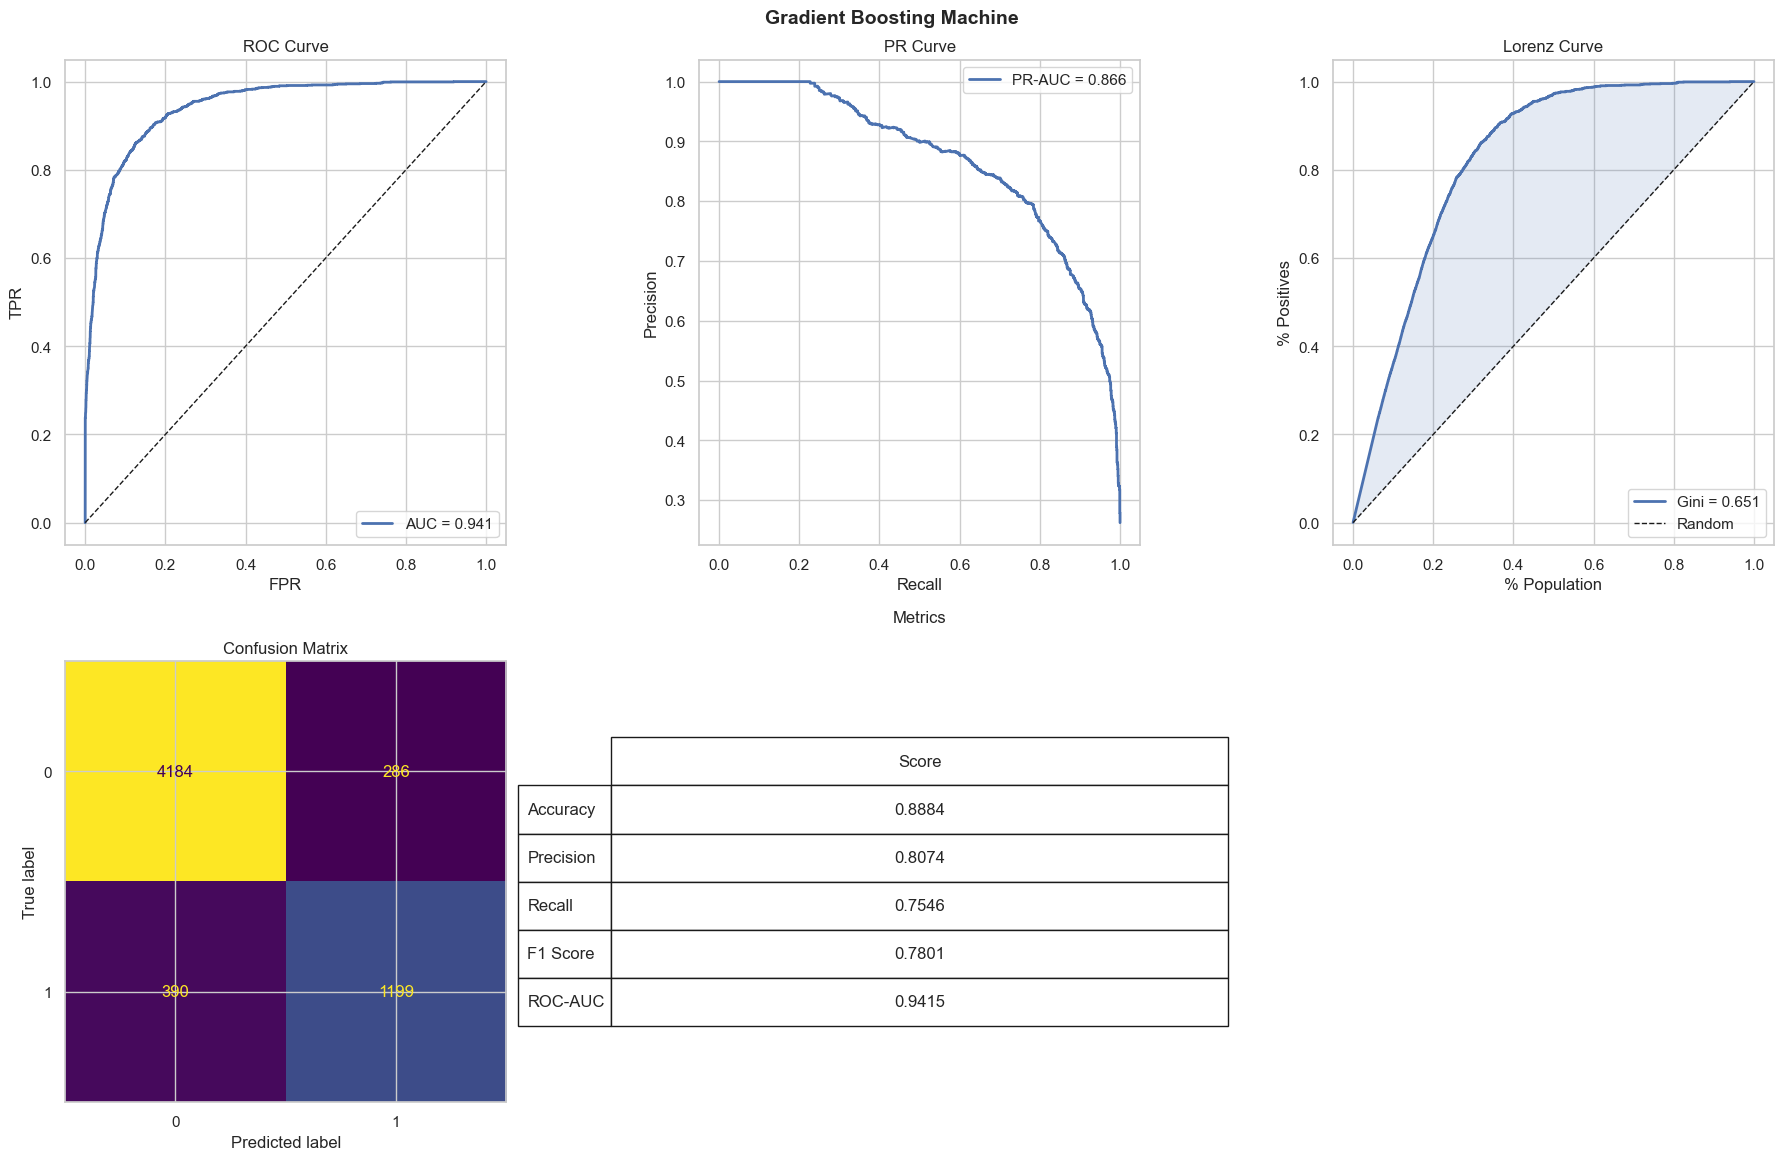

{'Model': 'Gradient Boosting Machine',
 'Accuracy': 0.8884304340650272,
 'Precision': 0.8074074074074075,
 'Recall': 0.7545626179987414,
 'F1 Score': 0.7800910865322056,
 'ROC-AUC': np.float64(0.9414646697161553)}

In [129]:
# Gradient Boosting Machine model

gbm_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbm_model.fit(X_train, y_train)

gbm_pred = gbm_model.predict(X_test)
gbm_prob = gbm_model.predict_proba(X_test)[:, 1]

gbm_results = evaluate_model(
    "Gradient Boosting Machine",
    y_test,
    gbm_pred,
    gbm_prob
)

gbm_results

In [130]:
# Gradient Boosting classification report

print(classification_report(y_test, gbm_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.94      0.93      4470
         1.0       0.81      0.75      0.78      1589

    accuracy                           0.89      6059
   macro avg       0.86      0.85      0.85      6059
weighted avg       0.89      0.89      0.89      6059



In [131]:
# Updated model comparison with GBM

model_results = pd.DataFrame([
    log_results,
    tree_results,
    rf_results,
    gbm_results
])

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.869120,0.775242,0.705475,0.738715,0.923465
1,Decision Tree,0.872751,0.751229,0.769666,0.760336,0.926101
2,Random Forest,0.871266,0.850824,0.617369,0.715536,0.928712
3,Gradient Boosting Machine,0.888430,0.807407,0.754563,0.780091,0.941465


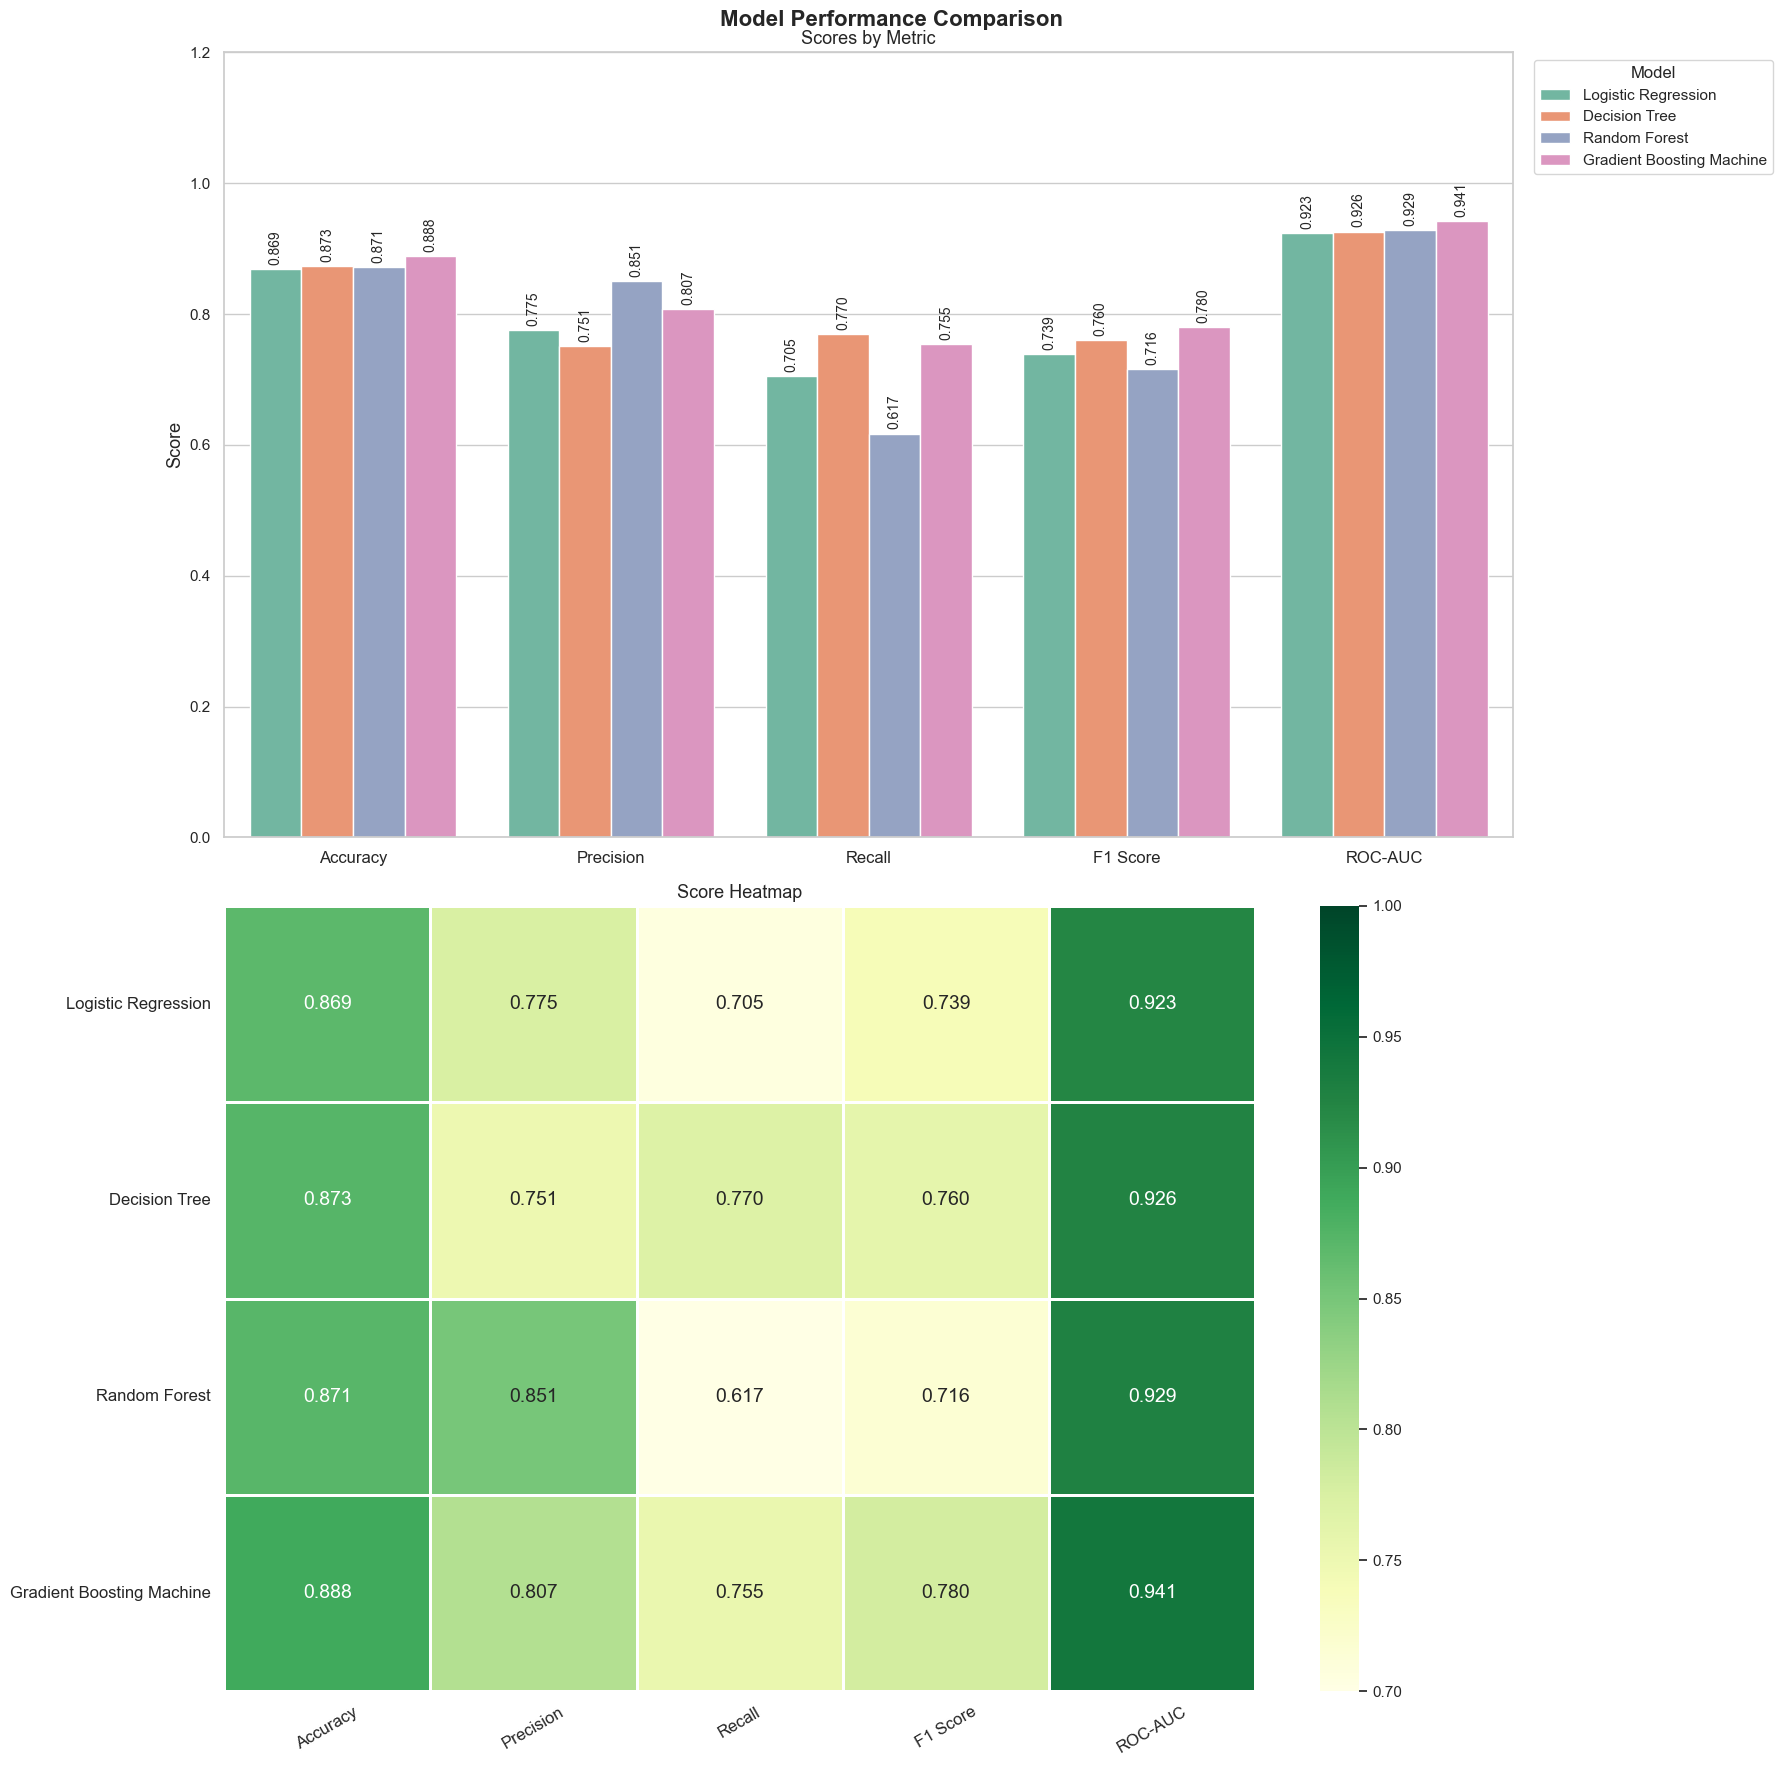

In [134]:
# Plot updated model comparison

model_results_melted = model_results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

fig, axes = plt.subplots(2, 1, figsize=(18, 18))
fig.suptitle("Model Performance Comparison", fontsize=16, fontweight="bold")

# --- Top: grouped bar chart with numbers ---
ax = axes[0]
sns.barplot(
    data=model_results_melted,
    x="Metric", y="Score", hue="Model",
    ax=ax, palette="Set2"
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=10, padding=3, rotation=90)

ax.set_ylim(0, 1.2)
ax.set_ylabel("Score", fontsize=13)
ax.set_xlabel("")
ax.tick_params(axis="x", labelsize=12)
ax.legend(title="Model", fontsize=11, title_fontsize=12,
          bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_title("Scores by Metric", fontsize=13)

# --- Bottom: heatmap ---
ax2 = axes[1]
heatmap_data = model_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]]
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".3f", cmap="YlGn",
    linewidths=0.8, linecolor="white",
    vmin=0.7, vmax=1.0,
    ax=ax2, annot_kws={"size": 14}
)
ax2.set_title("Score Heatmap", fontsize=13)
ax2.set_ylabel("")
ax2.tick_params(axis="x", labelsize=12, rotation=30)
ax2.tick_params(axis="y", labelsize=12, rotation=0)

plt.tight_layout()
plt.show()


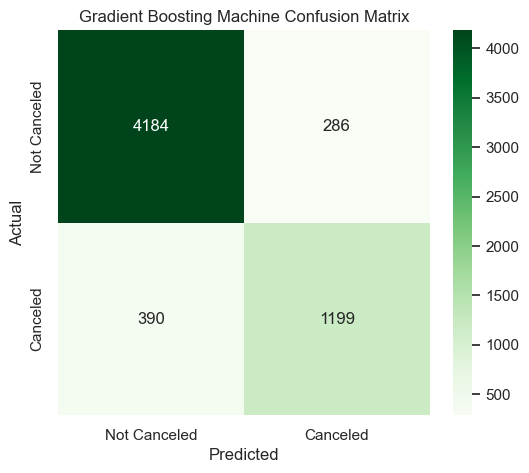

In [135]:
# Confusion matrix for Gradient Boosting Machine

gbm_cm = confusion_matrix(y_test, gbm_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    gbm_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Not Canceled", "Canceled"],
    yticklabels=["Not Canceled", "Canceled"]
)

plt.title("Gradient Boosting Machine Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [136]:
# Feature importance from Gradient Boosting Machine

gbm_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gbm_model.feature_importances_
})

gbm_feature_importance = gbm_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

gbm_feature_importance.head(20)

,Feature,Importance
133,country_PRT,0.189188
15,required_car_parking_spaces,0.140334
165,market_segment_Online TA,0.116164
1,arrival_date_year,0.093396
0,lead_time,0.086914
2,arrival_date_week_number,0.083604
17,room_match,0.075853
21,cancel_risk_score,0.070700
14,adr,0.034257
23,guest_loyalty,0.024886


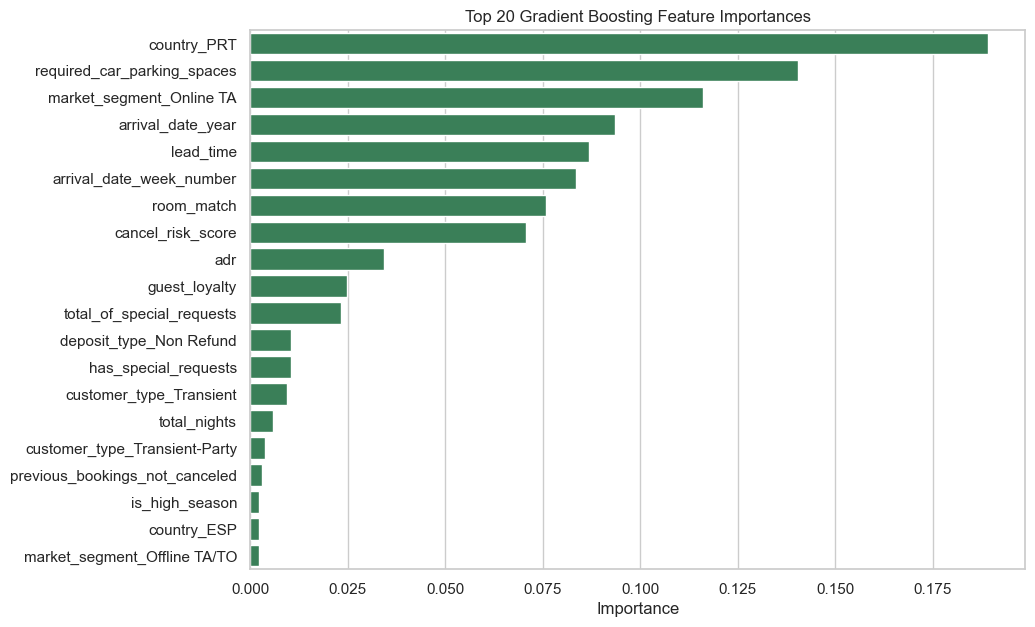

In [137]:
# Plot top 20 GBM important features

top_gbm_features = gbm_feature_importance.head(20)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_gbm_features,
    x="Importance",
    y="Feature",
    color="#2E8B57"
)

plt.title("Top 20 Gradient Boosting Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

A Gradient Boosting Machine was added because boosting methods build multiple weak learners sequentially, with each new tree correcting errors made by previous trees. This allows the model to capture complex nonlinear relationships between booking behavior and cancellation risk. Compared with a single Decision Tree, GBM usually performs better and is less simplistic. Compared with Random Forest, GBM may achieve stronger predictive performance because it learns from previous mistakes rather than building trees independently.

The feature importance results showed that country_PRT was the most influential predictor. This indicates that guests from Portugal had cancellation behavior that differed strongly from guests from other countries. Since the hotels in the dataset are located in Portugal, this may reflect local booking behavior. However, relying heavily on country may reduce the model’s generalizability to hotels outside Portugal or to future guest populations. Therefore, an additional model without the country feature should be evaluated to determine whether strong performance can be maintained without this geographic dependency.

In [87]:
# Train a second model without country

df_model_no_country = df_model.drop(columns=["country"])

X_no_country = df_model_no_country.drop(columns=["is_canceled"])
y_no_country = df_model_no_country["is_canceled"]

print("Features without country:", X_no_country.shape)
print("Target:", y_no_country.shape)

Features without country: (30293, 37)
Target: (30293,)


In [88]:
# Identify categorical and numeric columns again

categorical_cols_no_country = X_no_country.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_cols_no_country = X_no_country.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical columns without country:")
print(categorical_cols_no_country)

print("\nNumeric columns without country:")
print(numeric_cols_no_country)

Categorical columns without country:
['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'lead_time_group', 'adr_bin']

Numeric columns without country:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'room_match', 'total_nights', 'total_guests', 'is_high_season', 'cancel_risk_score', 'has_special_requests', 'guest_loyalty', 'weekend_ratio', 'booked_via_agent']


In [89]:
# One-hot encode categorical variables

X_no_country_encoded = pd.get_dummies(
    X_no_country,
    columns=categorical_cols_no_country,
    drop_first=True
)

X_no_country_encoded.shape

(30293, 78)

In [90]:
# Train-test split

X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_no_country_encoded,
    y_no_country,
    test_size=0.2,
    random_state=42,
    stratify=y_no_country
)

print("Training features without country:", X_train_nc.shape)
print("Testing features without country:", X_test_nc.shape)

Training features without country: (24234, 78)
Testing features without country: (6059, 78)


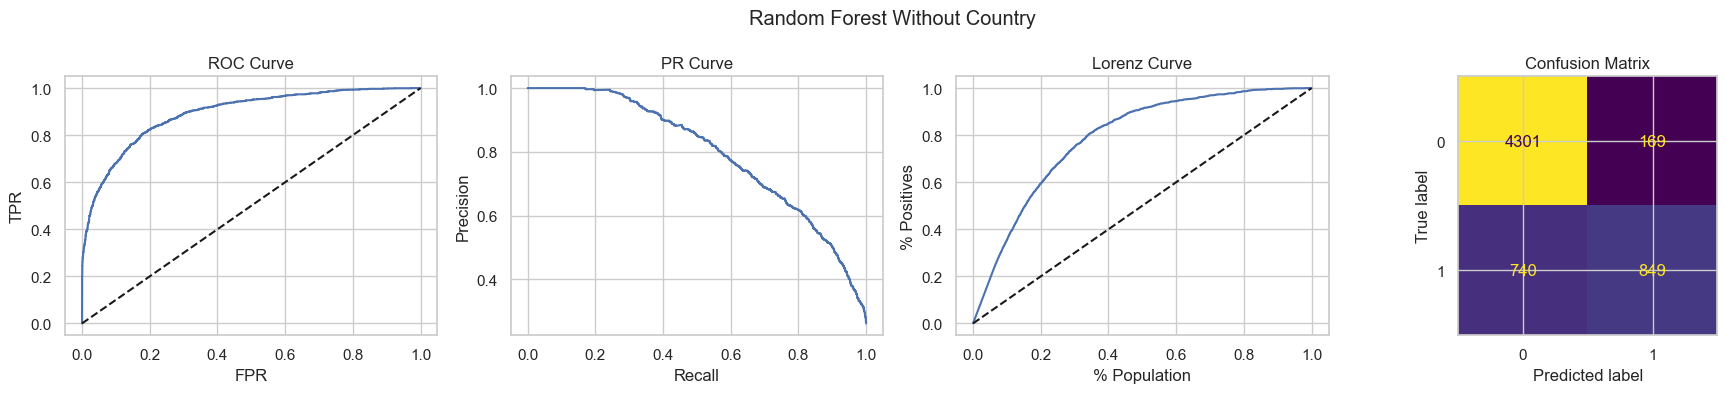

{'Model': 'Random Forest Without Country',
 'Accuracy': 0.8499752434395115,
 'Precision': 0.8339882121807466,
 'Recall': 0.5342983008181246,
 'F1 Score': 0.6513233601841196,
 'ROC-AUC': np.float64(0.892278922626615)}

In [91]:
# Train Random Forest without country

rf_model_nc = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=50,
    random_state=42,
    n_jobs=-1
)

rf_model_nc.fit(X_train_nc, y_train_nc)

rf_pred_nc = rf_model_nc.predict(X_test_nc)
rf_prob_nc = rf_model_nc.predict_proba(X_test_nc)[:, 1]

rf_results_nc = evaluate_model(
    "Random Forest Without Country",
    y_test_nc,
    rf_pred_nc,
    rf_prob_nc
)

rf_results_nc

In [92]:
# Classification report for Random Forest without country

print(classification_report(y_test_nc, rf_pred_nc))

              precision    recall  f1-score   support

         0.0       0.85      0.96      0.90      4470
         1.0       0.83      0.53      0.65      1589

    accuracy                           0.85      6059
   macro avg       0.84      0.75      0.78      6059
weighted avg       0.85      0.85      0.84      6059



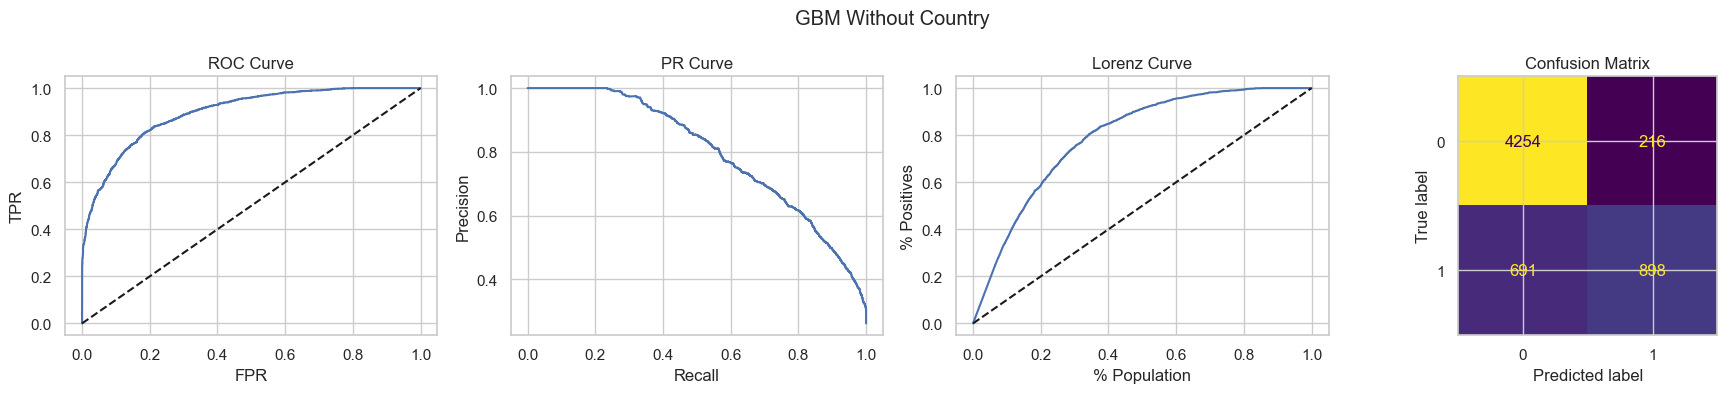

{'Model': 'GBM Without Country',
 'Accuracy': 0.8503053309126919,
 'Precision': 0.8061041292639138,
 'Recall': 0.5651353052234109,
 'F1 Score': 0.6644469108398077,
 'ROC-AUC': np.float64(0.896529059543872)}

In [93]:
# Train Gradient Boosting Machine without country

gbm_model_nc = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbm_model_nc.fit(X_train_nc, y_train_nc)

gbm_pred_nc = gbm_model_nc.predict(X_test_nc)
gbm_prob_nc = gbm_model_nc.predict_proba(X_test_nc)[:, 1]

gbm_results_nc = evaluate_model(
    "GBM Without Country",
    y_test_nc,
    gbm_pred_nc,
    gbm_prob_nc
)

gbm_results_nc

In [95]:
# Classification report for GBM without country

print(classification_report(y_test_nc, gbm_pred_nc))

              precision    recall  f1-score   support

         0.0       0.86      0.95      0.90      4470
         1.0       0.81      0.57      0.66      1589

    accuracy                           0.85      6059
   macro avg       0.83      0.76      0.78      6059
weighted avg       0.85      0.85      0.84      6059



In [96]:
# Compare original models with no-country models

country_comparison = pd.DataFrame([
    rf_results,
    gbm_results,
    rf_results_nc,
    gbm_results_nc
])

country_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.871266,0.850824,0.617369,0.715536,0.928712
1,Gradient Boosting Machine,0.888430,0.807407,0.754563,0.780091,0.941465
2,Random Forest Without Country,0.849975,0.833988,0.534298,0.651323,0.892279
3,GBM Without Country,0.850305,0.806104,0.565135,0.664447,0.896529


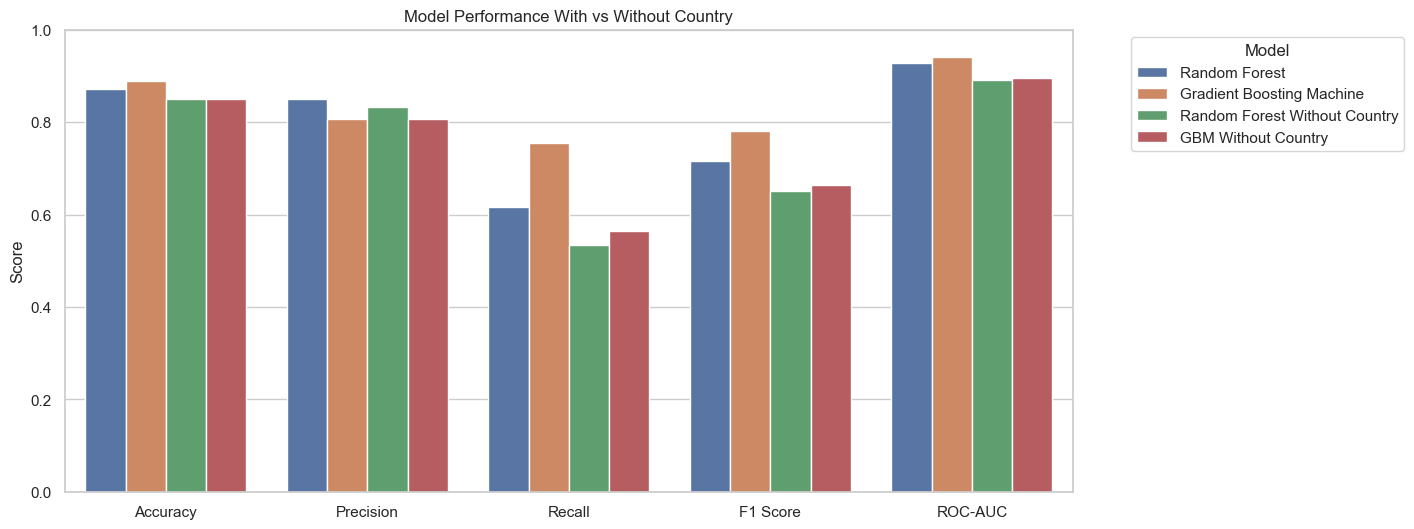

In [97]:
# Plot comparison

country_comparison_melted = country_comparison.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(13, 6))

sns.barplot(
    data=country_comparison_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Model Performance With vs Without Country")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [98]:
# Feature importance for Random Forest without country

feature_importance_nc = pd.DataFrame({
    "Feature": X_train_nc.columns,
    "Importance": rf_model_nc.feature_importances_
})

feature_importance_nc = feature_importance_nc.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_nc.head(20)

,Feature,Importance
15,required_car_parking_spaces,0.110649
1,arrival_date_year,0.095969
0,lead_time,0.095004
21,cancel_risk_score,0.083323
17,room_match,0.079039
45,market_segment_Online TA,0.077593
14,adr,0.054031
44,market_segment_Offline TA/TO,0.033733
2,arrival_date_week_number,0.031843
20,is_high_season,0.031032


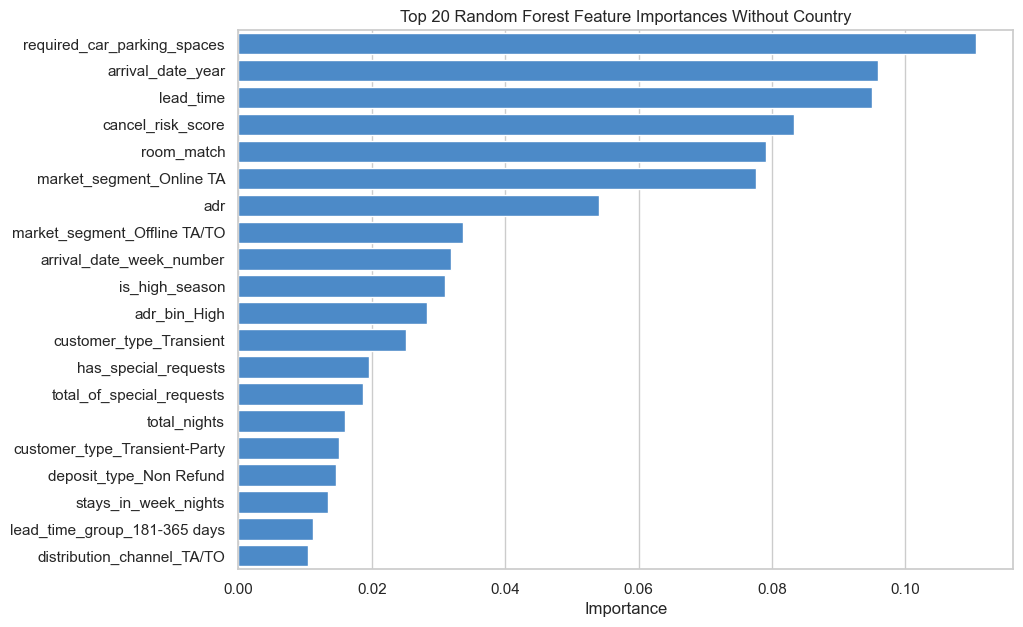

In [99]:
# Plot top 20 features without country

top_features_nc = feature_importance_nc.head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features_nc,
    x="Importance",
    y="Feature",
    color="#378ADD"
)

plt.title("Top 20 Random Forest Feature Importances Without Country")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

These results are very informative because they show two things at once: country improves prediction, and Gradient Boosting is the strongest model overall.

The fact that country_PRT was the most important feature makes sense because the hotels are located in Portugal. Guests from Portugal may cancel at different rates than international guests because of differences in travel distance, flexibility, booking behavior, or local travel patterns.

Although the model with country performed best, the dominance of country_PRT shows that the model relies strongly on geographic information. Because the dataset comes from hotels in Portugal, this feature improves prediction but may reduce generalizability to hotels in other countries.

Hyper-Tuning

In [101]:
# Tune Gradient Boosting Machine

gbm_param_grid = {
    "n_estimators": [100, 150, 200, 250, 300],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [20, 50, 100],
    "min_samples_leaf": [10, 20, 30],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

gbm_random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gbm_param_grid,
    n_iter=25,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

gbm_random_search.fit(X_train, y_train)

print("Best GBM parameters:")
print(gbm_random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(gbm_random_search.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best GBM parameters:
{'subsample': 1.0, 'n_estimators': 150, 'min_samples_split': 50, 'min_samples_leaf': 20, 'max_depth': 5, 'learning_rate': 0.1}

Best CV ROC-AUC:
0.951818534507796


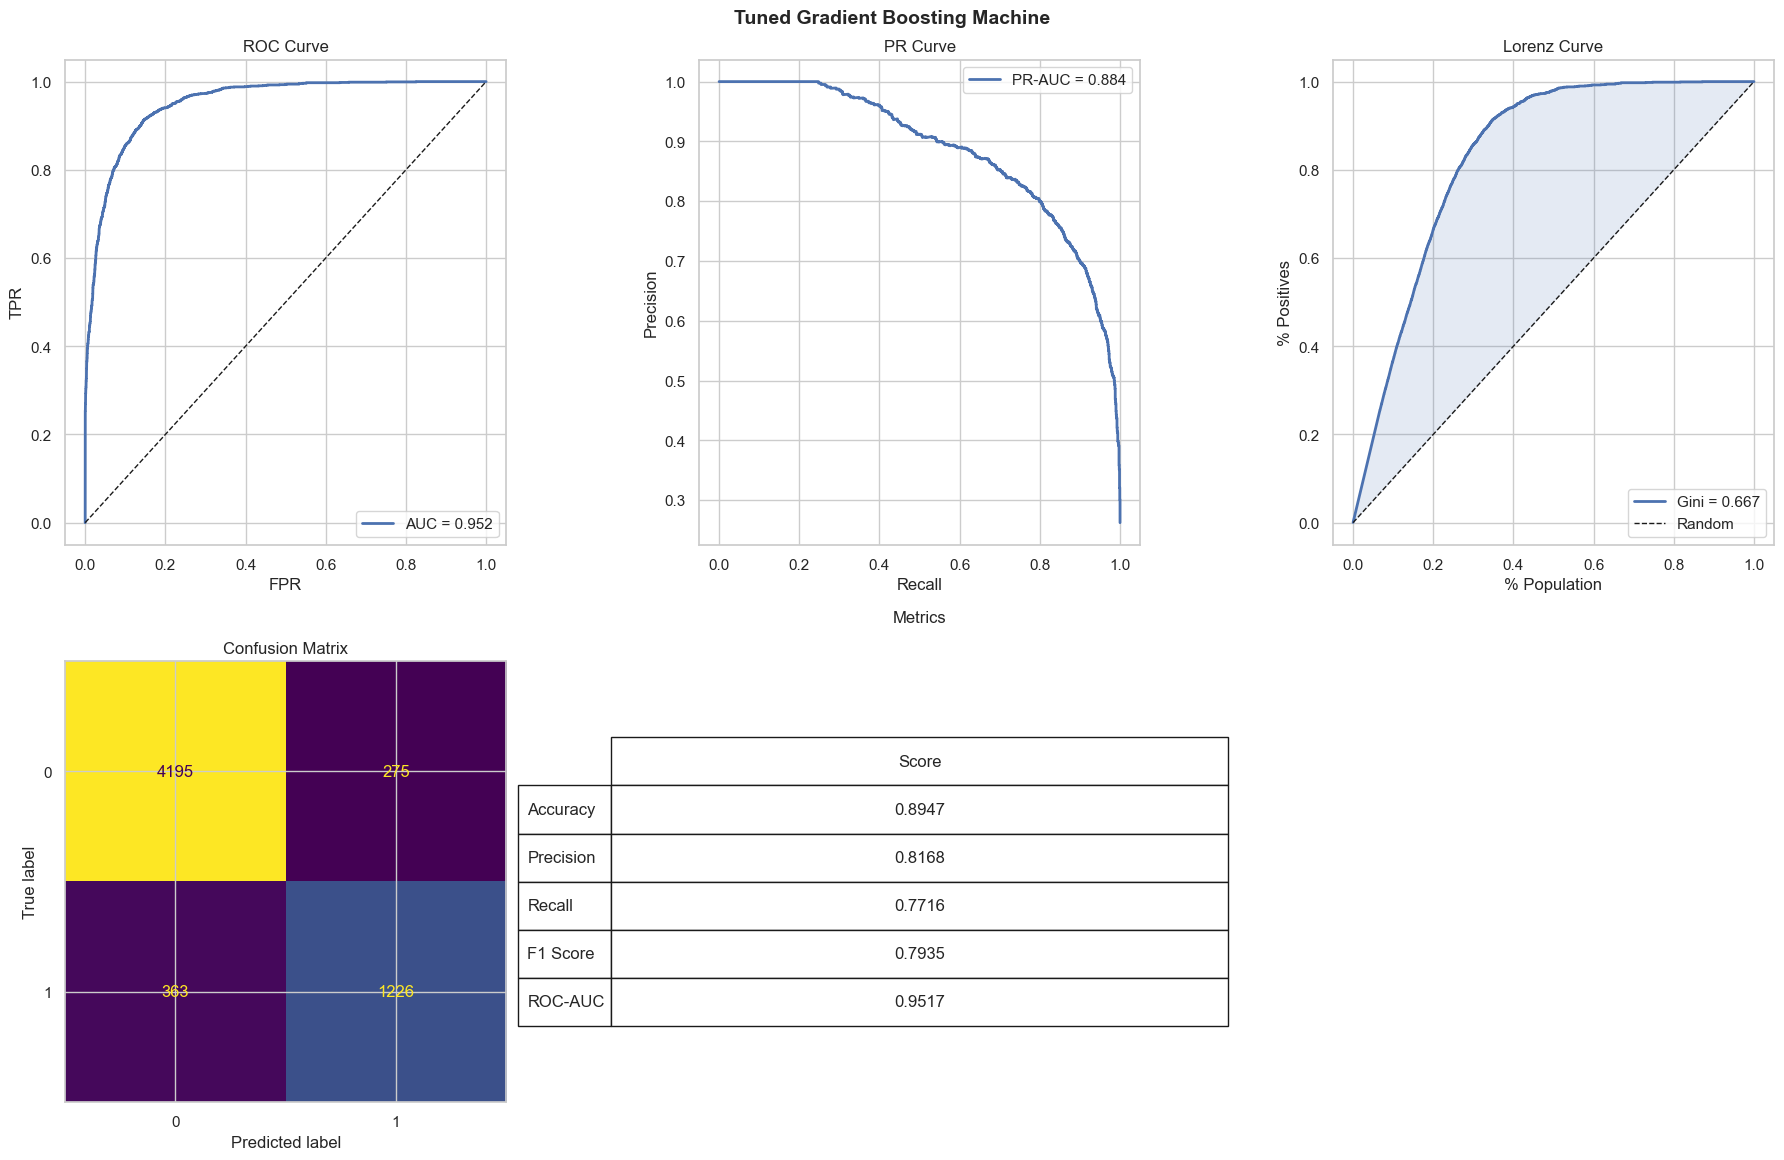

{'Model': 'Tuned Gradient Boosting Machine',
 'Accuracy': 0.8947020960554547,
 'Precision': 0.8167888074616922,
 'Recall': 0.7715544367526747,
 'F1 Score': 0.7935275080906149,
 'ROC-AUC': np.float64(0.951719596273598)}

In [138]:
# Evaluate tuned GBM on test set

best_gbm_model = gbm_random_search.best_estimator_

best_gbm_pred = best_gbm_model.predict(X_test)
best_gbm_prob = best_gbm_model.predict_proba(X_test)[:, 1]

best_gbm_results = evaluate_model(
    "Tuned Gradient Boosting Machine",
    y_test,
    best_gbm_pred,
    best_gbm_prob
)

best_gbm_results

In [103]:
# Classification report for tuned GBM

print(classification_report(y_test, best_gbm_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.94      0.93      4470
         1.0       0.82      0.77      0.79      1589

    accuracy                           0.89      6059
   macro avg       0.87      0.86      0.86      6059
weighted avg       0.89      0.89      0.89      6059



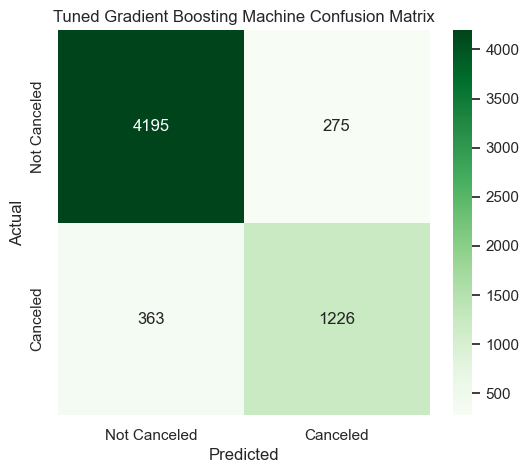

In [139]:
# Confusion matrix for tuned GBM

best_gbm_cm = confusion_matrix(y_test, best_gbm_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    best_gbm_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Not Canceled", "Canceled"],
    yticklabels=["Not Canceled", "Canceled"]
)

plt.title("Tuned Gradient Boosting Machine Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [140]:
# Compare tuned GBM with previous models

tuned_comparison = pd.DataFrame([
    rf_results,
    gbm_results,
    best_gbm_results
])

tuned_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.871266,0.850824,0.617369,0.715536,0.928712
1,Gradient Boosting Machine,0.888430,0.807407,0.754563,0.780091,0.941465
2,Tuned Gradient Boosting Machine,0.894702,0.816789,0.771554,0.793528,0.951720


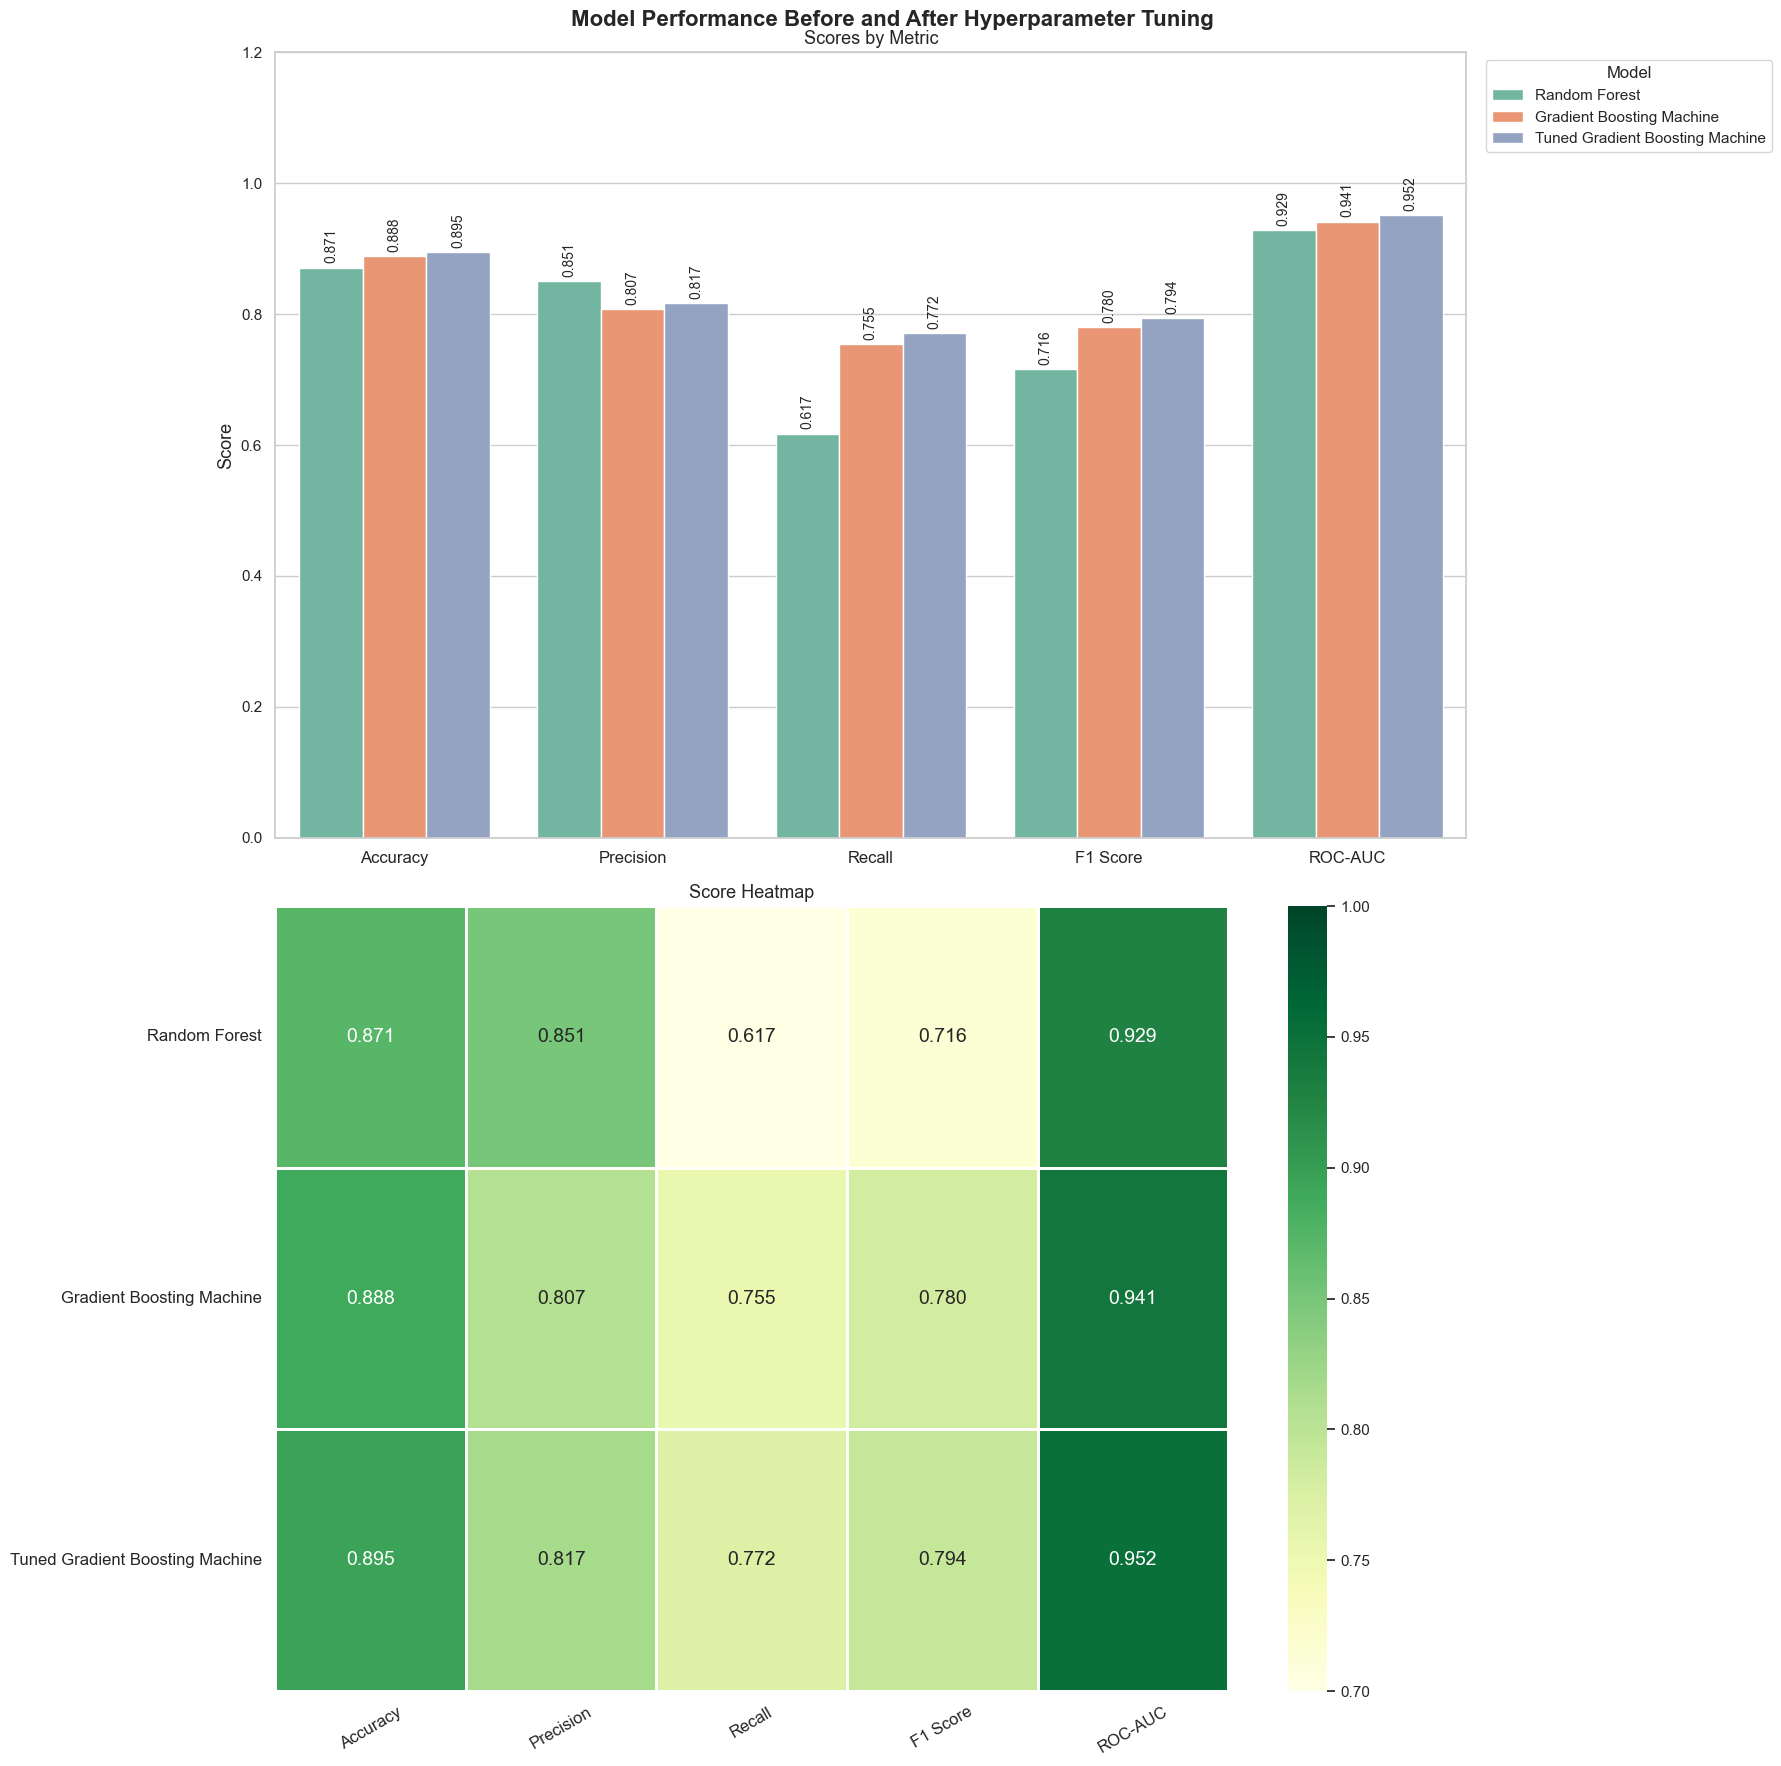

In [142]:
# Plot tuned model comparison

tuned_comparison_melted = tuned_comparison.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

fig, axes = plt.subplots(2, 1, figsize=(18, 18))
fig.suptitle("Model Performance Before and After Hyperparameter Tuning",
             fontsize=16, fontweight="bold")

# --- Top: bar chart with numbers ---
ax = axes[0]
sns.barplot(
    data=tuned_comparison_melted,
    x="Metric", y="Score", hue="Model",
    ax=ax, palette="Set2"
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=10, padding=3, rotation=90)

ax.set_ylim(0, 1.2)
ax.set_ylabel("Score", fontsize=13)
ax.set_xlabel("")
ax.tick_params(axis="x", labelsize=12)
ax.legend(title="Model", fontsize=11, title_fontsize=12,
          bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_title("Scores by Metric", fontsize=13)

# --- Bottom: heatmap ---
ax2 = axes[1]
heatmap_data = tuned_comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]]
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".3f", cmap="YlGn",
    linewidths=0.8, linecolor="white",
    vmin=0.7, vmax=1.0,
    ax=ax2, annot_kws={"size": 14}
)
ax2.set_title("Score Heatmap", fontsize=13)
ax2.set_ylabel("")
ax2.tick_params(axis="x", labelsize=12, rotation=30)
ax2.tick_params(axis="y", labelsize=12, rotation=0)

plt.tight_layout()
plt.show()


In [143]:
# Feature importance for tuned GBM

best_gbm_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_gbm_model.feature_importances_
})

best_gbm_feature_importance = best_gbm_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

best_gbm_feature_importance.head(20)

,Feature,Importance
133,country_PRT,0.152255
165,market_segment_Online TA,0.119848
15,required_car_parking_spaces,0.112654
2,arrival_date_week_number,0.094666
1,arrival_date_year,0.089310
0,lead_time,0.084463
17,room_match,0.082508
21,cancel_risk_score,0.073948
22,has_special_requests,0.037077
14,adr,0.030282


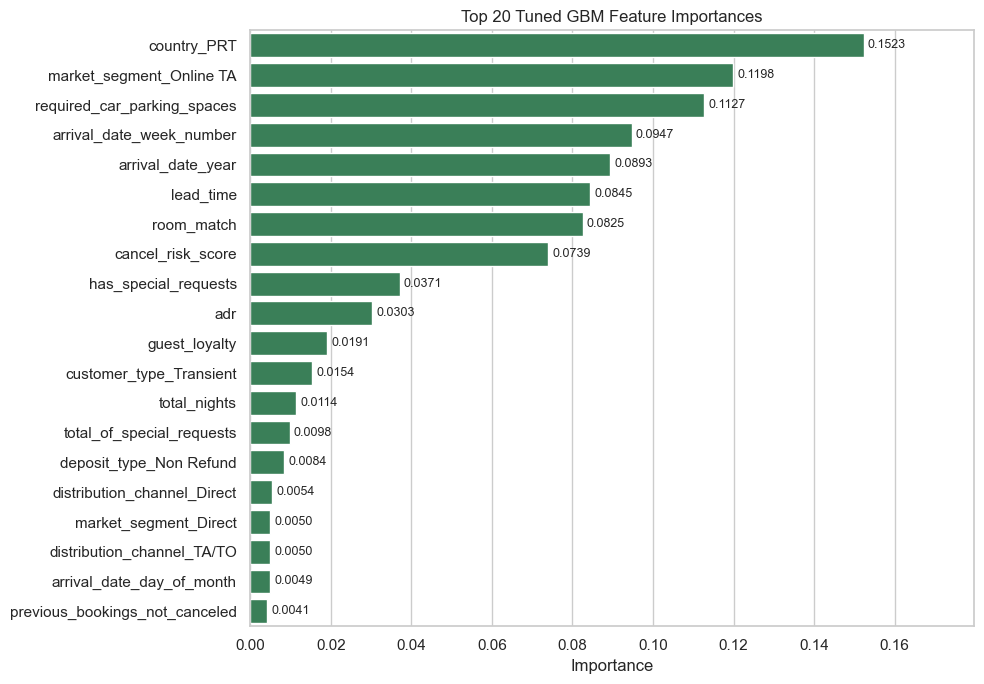

In [149]:
# Plot top 20 tuned GBM features

top_best_gbm_features = best_gbm_feature_importance.head(20)

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    data=top_best_gbm_features,
    x="Importance",
    y="Feature",
    color="#2E8B57",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=9, padding=3)

ax.set_xlim(0, top_best_gbm_features["Importance"].max() * 1.18)
ax.set_title("Top 20 Tuned GBM Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\write\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [21:08:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost parameters:
{'subsample': 1.0, 'reg_lambda': 10.0, 'reg_alpha': 0.01, 'n_estimators': 400, 'min_child_weight': 20, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Best CV ROC-AUC:
0.9500383701441988


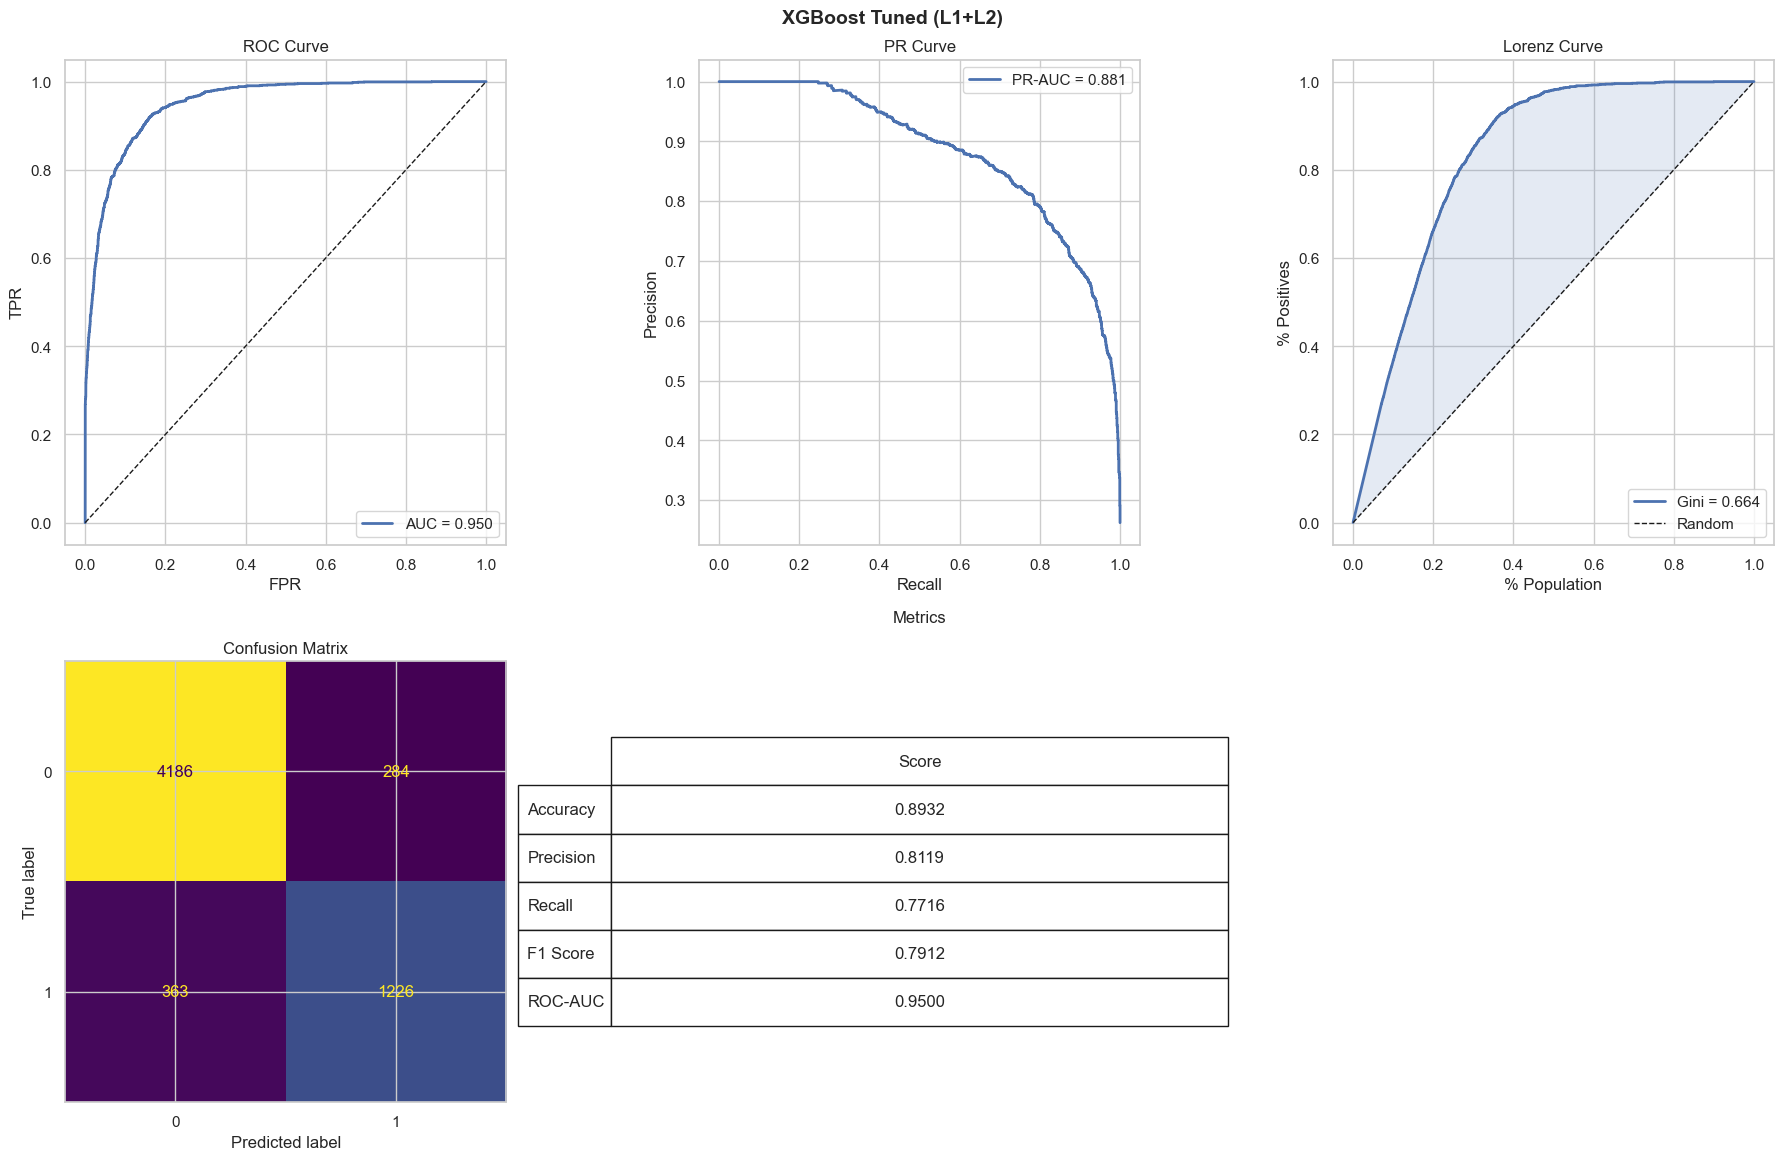

In [148]:
xgb_param_grid = [
    {
        "learning_rate":    [0.01],
        "n_estimators":     [300, 400, 500],
        "max_depth":        [2, 3, 4, 5],
        "min_child_weight": [20, 50, 100],   # equivalent to min_samples_leaf
        "subsample":        [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0], # equivalent to max_features
        "reg_alpha":        [0, 0.01, 0.1, 0.5, 1.0],   # L1
        "reg_lambda":       [0.5, 1.0, 2.0, 5.0, 10.0], # L2
    },
    {
        "learning_rate":    [0.05],
        "n_estimators":     [200, 300, 400],
        "max_depth":        [2, 3, 4, 5],
        "min_child_weight": [20, 50, 100],
        "subsample":        [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0],
        "reg_alpha":        [0, 0.01, 0.1, 0.5, 1.0],
        "reg_lambda":       [0.5, 1.0, 2.0, 5.0, 10.0],
    },
    {
        "learning_rate":    [0.1],
        "n_estimators":     [100, 150, 200],
        "max_depth":        [2, 3, 4, 5],
        "min_child_weight": [20, 50, 100],
        "subsample":        [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0],
        "reg_alpha":        [0, 0.01, 0.1, 0.5, 1.0],
        "reg_lambda":       [0.5, 1.0, 2.0, 5.0, 10.0],
    },
]

xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False
    ),
    param_distributions=xgb_param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

xgb_random_search.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(xgb_random_search.best_score_)

# Evaluate
best_xgb = xgb_random_search.best_estimator_
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]
results = evaluate_model("XGBoost Tuned (L1+L2)", y_test, y_pred, y_prob)

In [ ]:
# Save tuned GBM model for Streamlit app

joblib.dump(best_gbm_model, "hotel_cancellation_tuned_gbm.pkl")
joblib.dump(X_train.columns.tolist(), "model_columns_tuned_gbm.pkl")

print("Tuned GBM model saved successfully.")

Tuned GBM model saved successfully.
